# Recursive science still-life loop — trajectory ZIP + true FlowMorph

This notebook follows the same recursive, cyclic FlowMorph workflow as
`StillLife_Recursive_FlowMorph_Vision`, but the anchor paintings follow an
external image trajectory stored as a ZIP on Google Drive.

1. Edit the sciences/prompts and choose how many anchors to use.
2. Point `TRAJECTORY_ZIP_DIRECTORY` and `TRAJECTORY_ZIP_FILENAME` at the Drive archive.
3. The archive is naturally sorted and sampled at equal intervals. With 180
   images and 18 prompts, members `0, 10, …, 170` become the strong init frames.
4. FLUX.2 Klein + RIJKSOIL regenerates each sampled frame with its corresponding
   science prompt while retaining the source trajectory.
5. Vision midpoint prompting, cached/batched FlowMorph, streaming Drive outputs,
   cyclic assembly, batched RIFE, SSIM equalization, and MP4 export continue exactly
   as in the original notebook.

The ZIP is copied once to local Colab storage for efficient access. Only the
regularly sampled members are decoded and persisted into the run directory.


## 1. Editable run, trajectory ZIP, model, API, FlowMorph, image, and video settings

Every `BASE_STAGES` entry is used by default, with no ten-prompt ceiling.
True latent img2img plus reference conditioning preserve the selected source
frame's spatial layout instead of letting the prompt recenter the composition.


In [1]:
PROJECT_ROOT = "/content/FlowMorphKlein9B"
REPOSITORY_URL = "https://github.com/MNoichl/FluxFlowMorph.git"
UPDATE_REPOSITORY = True
PROJECT_NAME = "science_path_trajectory_flowmorph"
CONFIG_PATH = f"{PROJECT_ROOT}/configs/full_9b_lora.yaml"
PROFILE = "auto"
LOCAL_ASSET_ROOT = "/content/flowmorph_recursive_art"
HF_CACHE_DIR = "/content/hf_cache"

# Drive and secret. Put only the token text in this file (one line).
MOUNT_DRIVE = True
DRIVE_PROJECT_BASE = "/content/drive/MyDrive/FluxFlowMorphArt"
OPENAI_KEY_FILENAME = "openaiapikey.txt"
RESUME_RUN_DIRECTORY = None  # Example: "/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_vision/..."
# RESUME_RUN_DIRECTORY = "/content/drive/MyDrive/FluxFlowMorphArt/science_path_recursive_flowmorph/science_path_recursive_flowmorph_0008_20260722T111308Z"



# OpenAI vision prompt generation.
OPENAI_MODEL = "gpt-5.6"
OPENAI_REASONING_EFFORT = "medium"
OPENAI_IMAGE_DETAIL = "high"  # "low", "high", "original", or "auto"
# Includes hidden reasoning plus visible structured JSON. 5000 avoids
# cutting a valid proposal off in the middle of its prompt string.
OPENAI_MAX_OUTPUT_TOKENS = 5000
OPENAI_MAX_ATTEMPTS = 3
VISION_IMAGE_MAX_SIDE = 1024
VISION_JPEG_QUALITY = 90

# Editable anchor selection and recursive insertion.
BASE_PROMPT_COUNT = None  # None uses every BASE_STAGES entry; an integer caps the list.
FLOWMORPH_ROUND_SPECS = [
    {"midpoint_count": 1, "prompt_mode": "explicit_midpoint"},
    {"midpoint_count": 10, "prompt_mode": "shared_midpoint"},
]
INTERPOLATION_ROUNDS = len(FLOWMORPH_ROUND_SPECS)
REGENERATE_BASE_FRAMES = True
REUSE_EXISTING_MIDPOINTS = True
RESUME_FLOWMORPH_SEQUENCE = True

# Sequence-native true FlowMorph fitting/rendering.
FLOWMORPH_FIT_LORA_SCALE = 1.0
FLOWMORPH_RENDER_LORA_SCALE = 1.0
FLOWMORPH_GUIDANCE_SCALE = 4.0
FLOWMORPH_SCHEDULER_POINTS = 100
FLOWMORPH_START_TIMESTEP_INDEX = 35
FLOWMORPH_SOURCE_OPTIMIZATION_STEPS = 100
FLOWMORPH_TARGET_OPTIMIZATION_STEPS = 100
FLOWMORPH_PRED_LEARNING_RATE = 0.04
FLOWMORPH_U_LEARNING_RATE = 0.01
FLOWMORPH_RENDER_INDICES = [*range(35, 100, 5), 99]
FLOWMORPH_CHECKPOINT_EVERY = 25
FLOWMORPH_STREAM_PAIRS_PER_CHUNK = 3
FLOWMORPH_ENDPOINT_BATCH_SIZE = 2
FLOWMORPH_RENDER_BATCH_SIZE = 4
FLOWMORPH_DECODE_BATCH_SIZE = 8
FLOWMORPH_CFG_EXECUTION = "batched"
FLOWMORPH_BATCH_OOM_BACKOFF = True
OPENAI_CONCURRENCY = 6
FLOWMORPH_STREAM_DISPLAY_PROGRESS = True

# FLUX.2 Klein Base 9B + RIJKSOIL LoRA.
MODEL_ID = "Runware/BFL-FLUX.2-klein-base-9B"
MODEL_REVISION = "52d7274119d8a2b67f4fba1a43694d9169a44851"
LORA_SOURCE = "MaxNoichl/RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650"
LORA_REVISION = "042a31d6cd09bf55195f820461fac60b1a358409"
LORA_WEIGHT_NAME = "RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650.safetensors"
LORA_ADAPTER_NAME = "rijks_oil"
LORA_TRIGGER = "RIJKSOIL"

IMAGE_WIDTH = 1024
IMAGE_HEIGHT = 1024
IMAGE_INFERENCE_STEPS = 28
IMAGE_GUIDANCE_SCALE = 4.0
IMAGE_LORA_SCALE = 1.0
BASE_SEED = 98123479812734987 #1729

# Strong trajectory initialization for independently generated anchors.
TRAJECTORY_ZIP_DIRECTORY = "/content/drive/MyDrive/FluxFlowMorphArt/trajectory_inputs"
TRAJECTORY_ZIP_FILENAME = "background.zip"
TRAJECTORY_MEMBER_PREFIX = ""  # Optional folder inside the ZIP, without leading slash.
TRAJECTORY_FRAME_OFFSET = 0  # Rotate the naturally sorted trajectory before sampling.
TRAJECTORY_REVERSE_ORDER = False
TRAJECTORY_INIT_DETAIL_STRENGTH = 1.0  # 1 keeps the selected frame intact.
TRAJECTORY_INIT_BLUR = 0.0
TRAJECTORY_INIT_GRAIN_STRENGTH = 0.0
TRAJECTORY_DENOISE_STRENGTH = 0.12  # Lower preserves more source composition.
TRAJECTORY_COMPOSITION_INSTRUCTION = (
    "Use the reference image as a strict spatial map: preserve the placement, "
    "scale, silhouette, occupied areas, and empty areas; do not recenter or symmetrize."
)
TRAJECTORY_REMOVE_SYMMETRY_LANGUAGE = True  # Prevent prompt text from fighting the init layout.
SAVE_TRAJECTORY_REFERENCES = True

# Trial and notebook display.
RUN_TRIAL_KEYFRAME = True
TRIAL_KEYFRAME_INDEX = None  # None chooses randomly from the active prompt list.
TRIAL_SEED = None
TRIAL_DISPLAY_MAX_WIDTH = 768
RUN_FLOWMORPH_ONE_GAP_TEST = True
FLOWMORPH_ONE_GAP_TEST_INDEX = 0
FLOWMORPH_ONE_GAP_TEST_ALPHAS = [0.25, 0.5, 0.75]
CONTACT_SHEET_COLUMNS = 8
CONTACT_SHEET_DISPLAY_MAX_WIDTH = 1100
LOOP_PREVIEW_DISPLAY_WIDTH = 768
LOOP_PREVIEW_RENDER_MAX_SIDE = 512  # Reduced streaming preview; source PNGs stay untouched.

# Cyclic sequence and RIFE/SSIM finishing.
SOURCE_SEQUENCE_FPS = 12.0
LOOP_AUTO_ROTATE_TO_QUIETEST_CUT = True
LOOP_SEAM_ANALYSIS_SIZE = 192
RUN_RIFE_POSTPROCESS = True
RIFE_REPOSITORY_URL = "https://github.com/hzwer/Practical-RIFE.git"
RIFE_REPOSITORY_REVISION = "17d8c7a1005b37f4c97bfee04e316aaec7fdc536"
RIFE_ROOT = "/content/Practical-RIFE"
RIFE_MODEL_REPOSITORY = "Bash2X/RIFE-Models"
RIFE_MODEL_REVISION = "feaf6d11238b4a1e9f015a5d18c18df152affd20"
RIFE_MODEL_FILENAME = "RIFE_v4.25.zip"
RIFE_MULTIPLIER = 2
RIFE_SCALE = 1.0
RIFE_BATCH_SIZE = 4
RIFE_USE_FP16 = True
RIFE_RETRY_WITH_FP32 = True  # Automatically retry once when the fp16 runner fails.
RIFE_FINAL_FPS = 24.0
RIFE_SSIM_ANALYSIS_SIZE = 192
RIFE_SSIM_WEIGHT_FLOOR = 1e-6
RIFE_VIDEO_CRF = 16
RIFE_KEEP_WORK_FRAMES = False
RIFE_DISPLAY_WIDTH = 768
DOWNLOAD_FINAL_VIDEO = False


## 2. Editable anchor sciences and prompts

Edit these dictionaries directly. `science` is sent to the vision model as conceptual context; `prompt` is sent to FLUX. Every prompt must be a literal visual description and must contain the LoRA trigger `RIJKSOIL`. Avoid production-language such as “bridge frame,” “keep,” “same,” or “transition.”


In [7]:
BASE_STAGES =  [
    {
        "id": "01_cosmos_physics",
        "science": "Astronomy & Physics",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of the physical cosmos: a symmetrical festoon of night-blooming moonflowers and evening primrose encircling a central sun-and-moon medallion, trailing comet-vines and scattered stars worked into the scrollwork, a small armillary sphere and a prism nested among the leaves. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, chalky indigo-blue and pale gold, antique and weathered.",
    },
    {
        "id": "02_chemistry_materials",
        "science": "Chemistry & Materials",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of transformation: flowering vines twining around slender alembics and a pear-shaped retort, crystalline buds and mineral clusters sprouting from the scrollwork, sulphur-yellow blossoms and a garland of coiled distillation tubing, a central cartouche of a glowing crucible. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, warm amber and soft verdigris, antique and weathered.",
    },
    {
        "id": "03_geosciences",
        "science": "Geosciences & Earth",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of earth and sky: swags of fern, moss, and ivy braided with banded agates and shells, a terrestrial globe medallion wreathed in leaves, drifting cloud and wave motifs curling through the scrollwork, a small barometer nested among the fronds. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, cool slate-blue and mineral green, antique and weathered.",
    },
    {
        "id": "04_ecology_evolution",
        "science": "Ecology & Evolution",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of life and deep time: a teeming garland of wildflowers, grasses, and ferns inhabited by insects, snails, and small birds, a spiral ammonite curling as a decorative volute, a branching tree-of-life motif and a half-opened chrysalis worked into the scroll. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, mossy green and fossil-ochre, antique and weathered.",
    },
    {
        "id": "05_botany",
        "science": "Botany & Plant Science",
        "prompt": "RIJKSOIL, a lush floral fresco wall ornament of the plant kingdom: a full symmetrical festoon of tulips, roses, and poppies with fruiting branches and wheat sheaves, an herbarium ribbon of labelled specimens threaded through the scrollwork, a comb of honey and a magnifier tucked among the blooms. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, verdant green with rose-red and gold, antique and weathered.",
    },
    {
        "id": "06_genetics_cell",
        "science": "Genetics, Cell & Molecular Biology",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of heredity and the cell: pea-pod tendrils twisting into paired helical scrolls, split pomegranates set as seeded medallions, a honeycomb-lattice border, and rosettes of clustered berries standing for dividing cells. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, pale pearl-rose and warm ochre, antique and weathered.",
    },
    {
        "id": "07_medicine_body",
        "science": "Medicine & the Body",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of healing: a garland of medicinal poppy, foxglove, and willow around a serpent-and-staff entwined with flowering vines, an anatomical heart rendered as a delicate central medallion, apothecary phials and a single quiet memento-mori skull half-hidden among the leaves. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, soft carmine and ivory with herb-green, antique and weathered.",
    },
    {
        "id": "08_neuroscience_mind",
        "science": "Neuroscience & Mind",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of the mind: branching dendrite-vines and coral spreading symmetrically across the panel, a brain worked as an ornate central rosette, moths and songbirds perched in the scrollwork, a small labyrinth and a hanging pendulum among the tendrils. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, chalky blue-violet and dim silver, antique and weathered.",
    },
    {
        "id": "09_philosophy_society",
        "science": "Philosophy & Social Sciences",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of thought and society: a garland of laurel and olive framing a central cartouche of an owl perched on books beside an hourglass, scales of justice and a globe woven into the scrollwork, Platonic solids set as ornamental bosses among the leaves. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, warm sepia and old gold, antique and weathered.",
    },
    {
        "id": "10_computation_math",
        "science": "Computation & Mathematics",
        "prompt": "RIJKSOIL, a floral fresco wall ornament of pure form: interlacing arabesque lattice-work blooming into stylized geometric flowers, an orrery and interlocking clock gears woven through the scroll, a compass and Euclidean figures with nested Platonic solids, the ornament spiralling back toward a small sun and stars to close the circle. Sketched as a floral fresco wall ornament on aged lime plaster, loose confident linework and soft translucent washes, a symmetrical panel of garlands, festoons, and scrolling acanthus in the manner of Renaissance grottesche and Baroque wall painting, chalky faded pigments and hairline cracks, cool silver-grey and brass turning toward indigo, antique and weathered.",
    },
]


# Prompt count is resolved automatically from this list unless the optional cap is set.




## 3. GPU, repository, and compatible dependencies

This checks the actual imports needed by the notebook. It does not reject a healthy Diffusers install merely because editable-install provenance metadata is absent. A core reinstall happens only if a clean Python process cannot import the FLUX.2 Klein pipeline and required packages; in that case restart the kernel once after installation.


In [8]:
import platform
import subprocess
import sys
from pathlib import Path

print({"python": sys.version, "platform": platform.platform()})
try:
    import torch
except ImportError as error:
    raise RuntimeError("PyTorch is missing; use a Colab GPU runtime and rerun this cell.") from error
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU runtime is required.")
print({"gpu": torch.cuda.get_device_name(0), "cuda": torch.version.cuda})

project_path = Path(PROJECT_ROOT)
if not (project_path / "pyproject.toml").is_file():
    subprocess.check_call(["git", "clone", "--depth", "1", REPOSITORY_URL, PROJECT_ROOT])
elif UPDATE_REPOSITORY:
    subprocess.check_call(["git", "-C", PROJECT_ROOT, "pull", "--ff-only"])

core_probe = subprocess.run(
    [
        sys.executable,
        "-c",
        "import numpy, scipy, transformers, pydantic; from diffusers import Flux2KleinPipeline",
    ],
    capture_output=True,
    text=True,
)
if core_probe.returncode != 0:
    print("Installing the notebook's pinned FLUX environment because the clean import probe failed:")
    print(core_probe.stderr[-2000:])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-r",
        str(project_path / "requirements-colab.txt"),
    ])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", PROJECT_ROOT])
    raise RuntimeError(
        "Dependencies installed successfully. Restart the notebook kernel once, then rerun from section 1."
    )

try:
    import openai
    from openai import OpenAI
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "openai>=2,<3"])
    import openai
    from openai import OpenAI

import importlib
package_source = str(project_path / "src")
if package_source not in sys.path:
    sys.path.insert(0, package_source)
importlib.invalidate_caches()
import flowmorph_klein
from diffusers import Flux2KleinPipeline

project_commit = subprocess.check_output(
    ["git", "-C", PROJECT_ROOT, "rev-parse", "HEAD"], text=True
).strip()
print({
    "repository_commit": project_commit,
    "flowmorph_source": flowmorph_klein.__file__,
    "openai_sdk": openai.__version__,
})


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'platform': 'Linux-6.6.122+-x86_64-with-glibc2.35'}
{'gpu': 'NVIDIA RTX PRO 6000 Blackwell Server Edition', 'cuda': '12.8'}
{'repository_commit': 'be7cd13c74c1585c367f2d9f38d375d79fc418ac', 'flowmorph_source': '/content/FlowMorphKlein9B/src/flowmorph_klein/__init__.py', 'openai_sdk': '2.45.0'}


## 4. Mount Drive, reserve the run directory, and load the API key

Create `openaiapikey.txt` directly inside `DRIVE_PROJECT_BASE`. The file should contain only the API key and a final newline is optional. It is read into the OpenAI client and then the temporary string is deleted. The notebook prints the path it read, never the key or any key fragment.


In [9]:
import json
import re
from datetime import datetime, timezone

if not re.fullmatch(r"[A-Za-z0-9][A-Za-z0-9_-]*", PROJECT_NAME):
    raise ValueError("PROJECT_NAME may contain only letters, numbers, underscores, and hyphens")

DRIVE_ENABLED = False
if MOUNT_DRIVE:
    try:
        from google.colab import drive
    except ImportError as error:
        raise RuntimeError("Drive mounting requires a Google Colab kernel.") from error
    drive.mount("/content/drive")
    drive_base = Path(DRIVE_PROJECT_BASE)
    drive_base.mkdir(parents=True, exist_ok=True)
    DRIVE_ENABLED = True
else:
    drive_base = None

def reserve_numbered_run(parent, project_name):
    project_root = Path(parent) / project_name
    project_root.mkdir(parents=True, exist_ok=True)
    numbers = []
    prefix = f"{project_name}_"
    for candidate in project_root.iterdir():
        if candidate.is_dir() and candidate.name.startswith(prefix):
            token = candidate.name[len(prefix):].split("_", 1)[0]
            if token.isdigit():
                numbers.append(int(token))
    sequence = max(numbers, default=0) + 1
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    while True:
        candidate = project_root / f"{project_name}_{sequence:04d}_{timestamp}"
        try:
            candidate.mkdir(parents=False, exist_ok=False)
        except FileExistsError:
            sequence += 1
            continue
        return candidate

if RESUME_RUN_DIRECTORY is not None:
    RUN_DIRECTORY = Path(RESUME_RUN_DIRECTORY).expanduser()
    if not RUN_DIRECTORY.is_dir():
        raise FileNotFoundError(f"RESUME_RUN_DIRECTORY does not exist: {RUN_DIRECTORY}")
elif DRIVE_ENABLED:
    RUN_DIRECTORY = reserve_numbered_run(drive_base, PROJECT_NAME)
else:
    RUN_DIRECTORY = reserve_numbered_run(LOCAL_ASSET_ROOT, PROJECT_NAME)

for child in ("base_frames", "trials", "rounds", "previews", "video", "metadata"):
    (RUN_DIRECTORY / child).mkdir(parents=True, exist_ok=True)
Path(HF_CACHE_DIR).mkdir(parents=True, exist_ok=True)

if not DRIVE_ENABLED:
    raise RuntimeError(
        "This notebook's OpenAI key workflow expects Google Drive. Set MOUNT_DRIVE=True."
    )
OPENAI_KEY_PATH = drive_base / OPENAI_KEY_FILENAME
if not OPENAI_KEY_PATH.is_file():
    raise FileNotFoundError(
        f"Create {OPENAI_KEY_PATH} with only your OpenAI API key, then rerun this cell."
    )
_openai_key = OPENAI_KEY_PATH.read_text(encoding="utf-8").strip()
if len(_openai_key) < 20 or any(character.isspace() for character in _openai_key):
    raise ValueError("The Drive key file is empty or malformed; expected one token with no spaces.")
OPENAI_CLIENT = OpenAI(api_key=_openai_key)
del _openai_key

run_identity = {
    "project": PROJECT_NAME,
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "persistent": DRIVE_ENABLED,
    "run_directory": str(RUN_DIRECTORY),
    "openai_model": OPENAI_MODEL,
    "key_file": str(OPENAI_KEY_PATH),
    "key_value_recorded": False,
}
(RUN_DIRECTORY / "metadata" / "run_identity.json").write_text(
    json.dumps(run_identity, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
)
print("OpenAI client initialized from the Drive key file (credential value not displayed).")
print("Run directory:", RUN_DIRECTORY)
print("Every generated image and manifest is written directly into this persistent directory.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OpenAI client initialized from the Drive key file (credential value not displayed).
Run directory: /content/drive/MyDrive/FluxFlowMorphArt/science_path_trajectory_flowmorph/science_path_trajectory_flowmorph_0002_20260723T215257Z
Every generated image and manifest is written directly into this persistent directory.


## 5. Validate settings, stage the trajectory ZIP, and preview the recursive cost

The archive is copied from Drive to local Colab storage once, validated, naturally
sorted, and sampled according to the number of active prompts. The selected,
normalized source frames and their manifest are written directly into this run.


In [10]:
BASE_PROMPT_COUNT

10

In [11]:
ACTIVE_BASE_STAGES = (
    list(BASE_STAGES)
    if BASE_PROMPT_COUNT is None
    else list(BASE_STAGES[:max(0, int(BASE_PROMPT_COUNT))])
)
if not ACTIVE_BASE_STAGES:
    raise ValueError("BASE_STAGES must contain at least one active prompt")
BASE_PROMPT_COUNT = len(ACTIVE_BASE_STAGES)
if len(FLOWMORPH_ROUND_SPECS) != 2:
    raise ValueError("This notebook expects exactly two FlowMorph rounds")
allowed_prompt_modes = {"explicit_midpoint", "shared_midpoint"}
for index, spec in enumerate(FLOWMORPH_ROUND_SPECS, start=1):
    if spec.get("prompt_mode") not in allowed_prompt_modes:
        raise ValueError(f"Invalid prompt mode in round {index}: {spec}")
    if not 1 <= int(spec.get("midpoint_count", 0)) <= 20:
        raise ValueError(f"Round {index} midpoint_count must be between 1 and 20")
if FLOWMORPH_ROUND_SPECS[0] != {"midpoint_count": 1, "prompt_mode": "explicit_midpoint"}:
    raise ValueError("Round 1 must use one explicitly prompted midpoint")
if FLOWMORPH_ROUND_SPECS[1] != {"midpoint_count": 10, "prompt_mode": "shared_midpoint"}:
    raise ValueError("Round 2 must use ten renders sharing one interpolation prompt")
if not (256 <= IMAGE_WIDTH <= 2048 and IMAGE_WIDTH % 16 == 0):
    raise ValueError("IMAGE_WIDTH must be 256–2048 and divisible by 16")
if not (256 <= IMAGE_HEIGHT <= 2048 and IMAGE_HEIGHT % 16 == 0):
    raise ValueError("IMAGE_HEIGHT must be 256–2048 and divisible by 16")
if not 1 <= IMAGE_INFERENCE_STEPS <= 100:
    raise ValueError("IMAGE_INFERENCE_STEPS must be between 1 and 100")
if not 0 <= IMAGE_GUIDANCE_SCALE <= 20:
    raise ValueError("IMAGE_GUIDANCE_SCALE must be between 0 and 20")
if not 0 < IMAGE_LORA_SCALE <= 4:
    raise ValueError("IMAGE_LORA_SCALE must lie in (0, 4]")
if not TRAJECTORY_ZIP_FILENAME.casefold().endswith(".zip"):
    raise ValueError("TRAJECTORY_ZIP_FILENAME must name a .zip archive")
if not isinstance(TRAJECTORY_FRAME_OFFSET, int):
    raise ValueError("TRAJECTORY_FRAME_OFFSET must be an integer")
if not 0 <= TRAJECTORY_INIT_DETAIL_STRENGTH <= 1:
    raise ValueError("TRAJECTORY_INIT_DETAIL_STRENGTH must lie in [0, 1]")
if TRAJECTORY_INIT_BLUR < 0:
    raise ValueError("TRAJECTORY_INIT_BLUR cannot be negative")
if not 0 <= TRAJECTORY_INIT_GRAIN_STRENGTH <= 0.25:
    raise ValueError("TRAJECTORY_INIT_GRAIN_STRENGTH must lie in [0, 0.25]")
if not 0 < TRAJECTORY_DENOISE_STRENGTH <= 1:
    raise ValueError("TRAJECTORY_DENOISE_STRENGTH must lie in (0, 1]")

def trajectory_generation_prompt(prompt):
    base = prompt
    if TRAJECTORY_REMOVE_SYMMETRY_LANGUAGE:
        base = re.sub(r"\bsymmetr(?:ical|ically)\b", "", base, flags=re.IGNORECASE)
    return " ".join(base.split()) + " " + TRAJECTORY_COMPOSITION_INSTRUCTION
if OPENAI_IMAGE_DETAIL not in {"low", "high", "original", "auto"}:
    raise ValueError("OPENAI_IMAGE_DETAIL must be low, high, original, or auto")
if FLOWMORPH_START_TIMESTEP_INDEX != FLOWMORPH_RENDER_INDICES[0]:
    raise ValueError("The first render index must equal the FlowMorph start index")
if FLOWMORPH_RENDER_INDICES != sorted(set(FLOWMORPH_RENDER_INDICES)):
    raise ValueError("FLOWMORPH_RENDER_INDICES must be strictly increasing")
if FLOWMORPH_RENDER_INDICES[-1] >= FLOWMORPH_SCHEDULER_POINTS:
    raise ValueError("FLOWMORPH_RENDER_INDICES must be smaller than scheduler points")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS != FLOWMORPH_TARGET_OPTIMIZATION_STEPS:
    raise ValueError("Sequence-cached endpoints require one shared optimization-step count")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS < 1:
    raise ValueError("FlowMorph optimization steps must be positive")
if FLOWMORPH_SOURCE_OPTIMIZATION_STEPS != 100:
    raise ValueError("This quality-first notebook requires 100 endpoint fitting steps")
if FLOWMORPH_FIT_LORA_SCALE != IMAGE_LORA_SCALE:
    raise ValueError("FlowMorph fit LoRA scale must match IMAGE_LORA_SCALE")
if FLOWMORPH_RENDER_LORA_SCALE != IMAGE_LORA_SCALE:
    raise ValueError("FlowMorph render LoRA scale must match IMAGE_LORA_SCALE")
if FLOWMORPH_GUIDANCE_SCALE != IMAGE_GUIDANCE_SCALE:
    raise ValueError("FlowMorph guidance must match IMAGE_GUIDANCE_SCALE")
if FLOWMORPH_STREAM_PAIRS_PER_CHUNK < 1:
    raise ValueError("FLOWMORPH_STREAM_PAIRS_PER_CHUNK must be positive")
for name, value in {
    "FLOWMORPH_ENDPOINT_BATCH_SIZE": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "FLOWMORPH_RENDER_BATCH_SIZE": FLOWMORPH_RENDER_BATCH_SIZE,
    "FLOWMORPH_DECODE_BATCH_SIZE": FLOWMORPH_DECODE_BATCH_SIZE,
    "OPENAI_CONCURRENCY": OPENAI_CONCURRENCY,
}.items():
    if value < 1:
        raise ValueError(f"{name} must be positive")
if FLOWMORPH_CFG_EXECUTION not in {"sequential", "batched"}:
    raise ValueError("FLOWMORPH_CFG_EXECUTION must be sequential or batched")
if not 0 <= FLOWMORPH_ONE_GAP_TEST_INDEX < BASE_PROMPT_COUNT:
    raise ValueError("FLOWMORPH_ONE_GAP_TEST_INDEX is outside the active anchor range")
if (
    not FLOWMORPH_ONE_GAP_TEST_ALPHAS
    or FLOWMORPH_ONE_GAP_TEST_ALPHAS != sorted(set(FLOWMORPH_ONE_GAP_TEST_ALPHAS))
    or any(not 0.0 < alpha < 1.0 for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS)
):
    raise ValueError("FLOWMORPH_ONE_GAP_TEST_ALPHAS must be unique sorted interior values")

# ACTIVE_BASE_STAGES was resolved above without an upper prompt-count check.
ids = [item["id"] for item in ACTIVE_BASE_STAGES]
if len(ids) != len(set(ids)) or any(not re.fullmatch(r"[a-z0-9_]+", item) for item in ids):
    raise ValueError("Anchor IDs must be unique lowercase snake_case values")
for item in ACTIVE_BASE_STAGES:
    if not item["science"].strip() or not item["prompt"].strip():
        raise ValueError(f"Blank science or prompt in {item['id']}")
    if item["prompt"].casefold().count(LORA_TRIGGER.casefold()) != 1:
        raise ValueError(f"{item['id']} must contain the LoRA trigger exactly once")

round_counts = [BASE_PROMPT_COUNT]
for spec in FLOWMORPH_ROUND_SPECS:
    round_counts.append(round_counts[-1] * (int(spec["midpoint_count"]) + 1))
pair_renders = sum(round_counts[:-1])
openai_calls = pair_renders  # One image-aware prompt per gap in both modes.
unique_endpoint_fits = round_counts[-2]
print({
    "anchor_images": BASE_PROMPT_COUNT,
    "sequence_counts": round_counts,
    "openai_vision_calls": openai_calls,
    "sequence_pair_renders": pair_renders,
    "unique_endpoint_fits": unique_endpoint_fits,
    "final_generated_sequence_images": round_counts[-1],
    "round_specs": FLOWMORPH_ROUND_SPECS,
    "rife_multiplier": RIFE_MULTIPLIER,
})
print("Anchor order:", " → ".join(ids), "→", ids[0])
import hashlib
import shutil
from flowmorph_klein.trajectory import stage_regular_keyframes

TRAJECTORY_DRIVE_ARCHIVE = (
    Path(TRAJECTORY_ZIP_DIRECTORY).expanduser() / TRAJECTORY_ZIP_FILENAME
)
if not TRAJECTORY_DRIVE_ARCHIVE.is_file():
    raise FileNotFoundError(
        f"Trajectory ZIP was not found: {TRAJECTORY_DRIVE_ARCHIVE}. "
        "Upload it to Drive or edit the two trajectory path settings."
    )
trajectory_cache = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "trajectory_archive"
trajectory_cache.mkdir(parents=True, exist_ok=True)
TRAJECTORY_LOCAL_ARCHIVE = trajectory_cache / TRAJECTORY_ZIP_FILENAME
copy_state_path = trajectory_cache / "copy_state.json"
drive_stat = TRAJECTORY_DRIVE_ARCHIVE.stat()
drive_signature = {
    "source": str(TRAJECTORY_DRIVE_ARCHIVE),
    "size": drive_stat.st_size,
    "mtime_ns": drive_stat.st_mtime_ns,
}
saved_copy_state = (
    json.loads(copy_state_path.read_text(encoding="utf-8"))
    if copy_state_path.is_file()
    else None
)
if (
    not TRAJECTORY_LOCAL_ARCHIVE.is_file()
    or saved_copy_state != drive_signature
    or TRAJECTORY_LOCAL_ARCHIVE.stat().st_size != drive_stat.st_size
):
    print("Copying trajectory ZIP from Drive to local Colab storage...")
    shutil.copy2(TRAJECTORY_DRIVE_ARCHIVE, TRAJECTORY_LOCAL_ARCHIVE)
    copy_state_path.write_text(
        json.dumps(drive_signature, indent=2) + "\n",
        encoding="utf-8",
    )
else:
    print("Reusing the matching local trajectory ZIP copy.")

archive_hasher = hashlib.sha256()
with TRAJECTORY_LOCAL_ARCHIVE.open("rb") as archive_handle:
    for archive_chunk in iter(lambda: archive_handle.read(1024 * 1024), b""):
        archive_hasher.update(archive_chunk)
TRAJECTORY_ARCHIVE_SHA256 = archive_hasher.hexdigest()
BASE_DIRECTORY = RUN_DIRECTORY / "base_frames"
TRAJECTORY_SOURCE_DIRECTORY = BASE_DIRECTORY / "trajectory_sources"
TRAJECTORY_RECORDS = list(stage_regular_keyframes(
    TRAJECTORY_LOCAL_ARCHIVE,
    TRAJECTORY_SOURCE_DIRECTORY,
    keyframe_count=len(ACTIVE_BASE_STAGES),
    width=IMAGE_WIDTH,
    height=IMAGE_HEIGHT,
    member_prefix=TRAJECTORY_MEMBER_PREFIX,
    frame_offset=TRAJECTORY_FRAME_OFFSET,
    reverse_order=TRAJECTORY_REVERSE_ORDER,
))
for trajectory_record, stage in zip(TRAJECTORY_RECORDS, ACTIVE_BASE_STAGES, strict=True):
    trajectory_record["stage_id"] = stage["id"]
    trajectory_record["science"] = stage["science"]
    trajectory_record["prompt"] = stage["prompt"]

TRAJECTORY_SELECTION_MANIFEST = (
    RUN_DIRECTORY / "metadata" / "trajectory_selection.json"
)
TRAJECTORY_SELECTION_MANIFEST.write_text(json.dumps({
    "archive_drive_path": str(TRAJECTORY_DRIVE_ARCHIVE),
    "archive_local_path": str(TRAJECTORY_LOCAL_ARCHIVE),
    "archive_sha256": TRAJECTORY_ARCHIVE_SHA256,
    "selection_rule": "floor(keyframe_index * image_count / keyframe_count)",
    "member_prefix": TRAJECTORY_MEMBER_PREFIX,
    "frame_offset": TRAJECTORY_FRAME_OFFSET,
    "reverse_order": TRAJECTORY_REVERSE_ORDER,
    "keyframe_count": len(TRAJECTORY_RECORDS),
    "records": TRAJECTORY_RECORDS,
}, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print({
    "trajectory_archive": str(TRAJECTORY_DRIVE_ARCHIVE),
    "archive_sha256": TRAJECTORY_ARCHIVE_SHA256,
    "selected_keyframes": len(TRAJECTORY_RECORDS),
    "selected_indices": [
        record["trajectory_index"] for record in TRAJECTORY_RECORDS
    ],
    "selection_manifest": str(TRAJECTORY_SELECTION_MANIFEST),
})


{'anchor_images': 10, 'sequence_counts': [10, 20, 220], 'openai_vision_calls': 30, 'sequence_pair_renders': 30, 'unique_endpoint_fits': 20, 'final_generated_sequence_images': 220, 'round_specs': [{'midpoint_count': 1, 'prompt_mode': 'explicit_midpoint'}, {'midpoint_count': 10, 'prompt_mode': 'shared_midpoint'}], 'rife_multiplier': 2}
Anchor order: 01_cosmos_physics → 02_chemistry_materials → 03_geosciences → 04_ecology_evolution → 05_botany → 06_genetics_cell → 07_medicine_body → 08_neuroscience_mind → 09_philosophy_society → 10_computation_math → 01_cosmos_physics
Copying trajectory ZIP from Drive to local Colab storage...
{'trajectory_archive': '/content/drive/MyDrive/FluxFlowMorphArt/trajectory_inputs/background.zip', 'archive_sha256': '21bf00cf055524c88ded9f3864e081188496edd05a72e0d5c8681acca698ab4b', 'selected_keyframes': 10, 'selected_indices': [0, 9, 18, 27, 36, 45, 54, 63, 72, 81], 'selection_manifest': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_trajectory_flowmorph/

## 6. Load and fuse RIJKSOIL; optional strong-init trial and FlowMorph test

The optional trial now uses the selected trajectory frame corresponding to the
chosen prompt. It displays both the actual conditioning image and the regenerated
painting so trajectory adherence can be checked before producing all anchors.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650(…): reconstructing file:   0%|          |  0.00B /  663MB            

RIJKSOIL_FLUX2_KLEIN9B_lora_01_000001650(…): downloading bytes:           |  0.00B            

model_index.json:   0%|          | 0.00/422 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Loading weights:   0%|          | 0/399 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded a device-safe fused-LoRA pipeline.


  0%|          | 0/28 [00:00<?, ?it/s]

### Trial trajectory input: `frame_062.jpg`

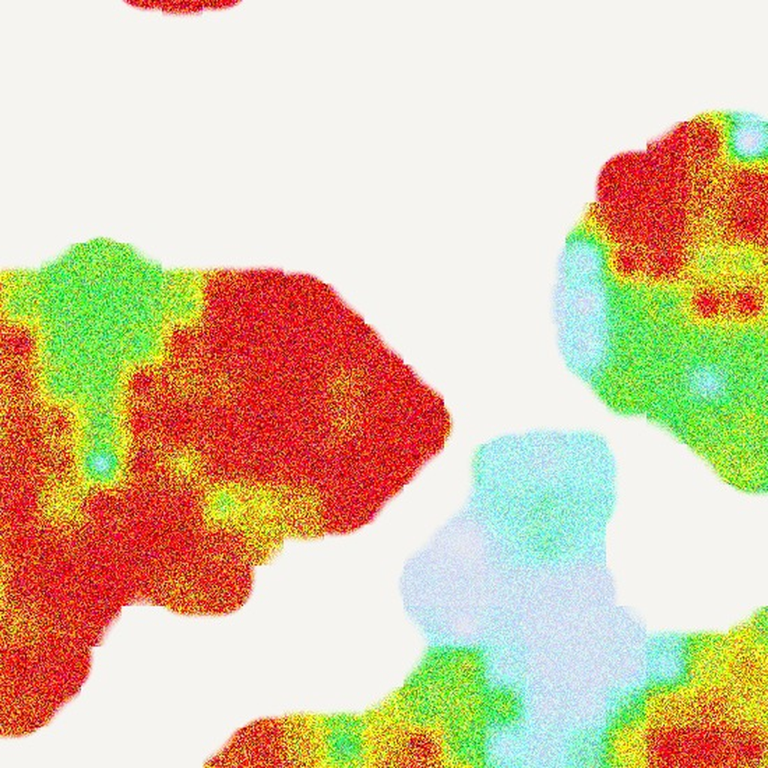

### Trial regenerated anchor: `03_geosciences`

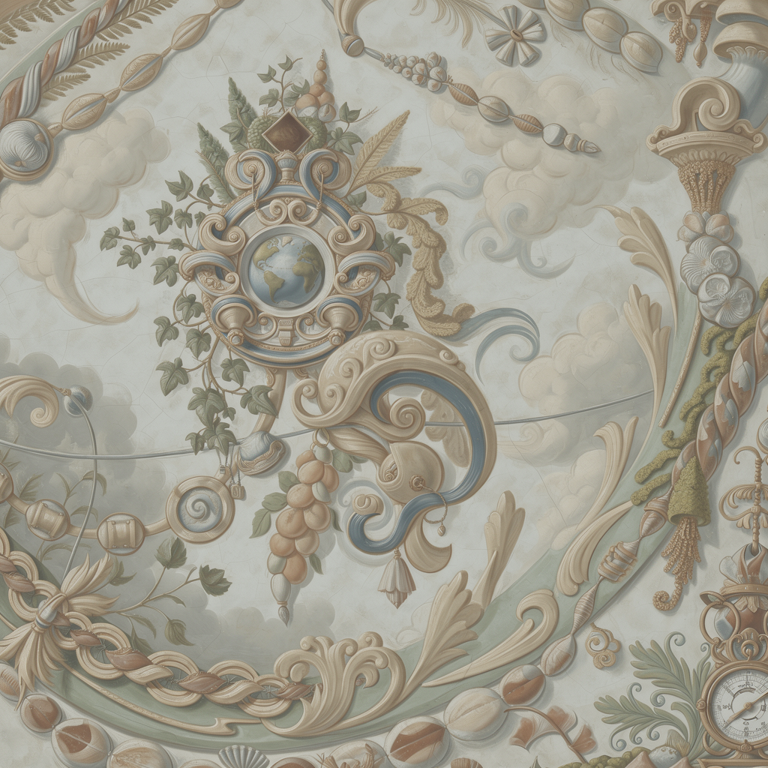

{'path': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_trajectory_flowmorph/science_path_trajectory_flowmorph_0002_20260723T215257Z/trials/20260723T215636Z_03_geosciences_1047549866/trial.png', 'trajectory_reference': '/content/drive/MyDrive/FluxFlowMorphArt/science_path_trajectory_flowmorph/science_path_trajectory_flowmorph_0002_20260723T215257Z/trials/20260723T215636Z_03_geosciences_1047549866/trajectory_reference.png', 'seed': 1047549866, 'prompt_index': 2}


In [12]:
import gc
import os
import random
import shutil
from huggingface_hub import hf_hub_download
from IPython.display import Markdown, display
from PIL import Image, ImageFilter
from flowmorph_klein.lora import load_flux2_lora
from flowmorph_klein.trajectory import (
    make_strong_trajectory_reference,
    prepare_flux2_klein_img2img_inputs,
)

try:
    import peft.tuners.lora.torchao as peft_torchao_dispatch
except ImportError:
    peft_torchao_dispatch = None
else:
    peft_torchao_dispatch.is_torchao_available = lambda: False

downloaded_lora = Path(hf_hub_download(
    repo_id=LORA_SOURCE,
    filename=LORA_WEIGHT_NAME,
    revision=LORA_REVISION,
    cache_dir=HF_CACHE_DIR,
))
lora_stage_directory = Path(HF_CACHE_DIR) / "flowmorph_lora_files" / LORA_REVISION[:12]
lora_stage_directory.mkdir(parents=True, exist_ok=True)
LOCAL_LORA_PATH = lora_stage_directory / LORA_WEIGHT_NAME
if not LOCAL_LORA_PATH.is_file():
    try:
        os.link(downloaded_lora.resolve(), LOCAL_LORA_PATH)
    except OSError:
        shutil.copy2(downloaded_lora, LOCAL_LORA_PATH)
if LOCAL_LORA_PATH.stat().st_size != downloaded_lora.stat().st_size:
    raise RuntimeError(f"Staged LoRA size mismatch at {LOCAL_LORA_PATH}")

def release_flux_pipeline():
    previous = globals().pop("FLUX_PIPE", None)
    globals().pop("FLUX_PIPE_LORA_SCALE", None)
    if previous is not None:
        maybe_free = getattr(previous, "maybe_free_model_hooks", None)
        if callable(maybe_free):
            maybe_free()
        del previous
        gc.collect()
        torch.cuda.empty_cache()

def load_flux_pipeline():
    pipeline = Flux2KleinPipeline.from_pretrained(
        MODEL_ID,
        revision=MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
    )
    report = load_flux2_lora(
        pipeline,
        str(LOCAL_LORA_PATH),
        adapter_name=LORA_ADAPTER_NAME,
        scale=IMAGE_LORA_SCALE,
        require_base_9b_provenance=False,
        allow_distilled_9b=True,
    )
    pipeline.fuse_lora(
        components=["transformer"],
        lora_scale=1.0,
        safe_fusing=True,
        adapter_names=[LORA_ADAPTER_NAME],
    )
    pipeline.unload_lora_weights()
    remaining = [
        name for name, _ in pipeline.transformer.named_parameters()
        if "lora_" in name.casefold() or ".lora" in name.casefold()
    ]
    if remaining:
        raise RuntimeError("LoRA fusion left runtime parameters: " + ", ".join(remaining[:5]))
    pipeline.enable_model_cpu_offload()
    pipeline.vae.enable_slicing()
    pipeline.vae.enable_tiling()
    return pipeline, report

if "FLUX_PIPE" in globals() and globals().get("FLUX_PIPE_LORA_SCALE") != float(IMAGE_LORA_SCALE):
    print("LoRA scale changed; rebuilding the fused pipeline.")
    release_flux_pipeline()
if "FLUX_PIPE" not in globals():
    FLUX_PIPE, LORA_REPORT = load_flux_pipeline()
    FLUX_PIPE_LORA_SCALE = float(IMAGE_LORA_SCALE)
    print("Loaded a device-safe fused-LoRA pipeline.")
else:
    print("Reusing the fused pipeline at the current LoRA scale.")

if RUN_TRIAL_KEYFRAME:
    system_random = random.SystemRandom()
    trial_index = (
        TRIAL_KEYFRAME_INDEX
        if TRIAL_KEYFRAME_INDEX is not None
        else system_random.randrange(len(ACTIVE_BASE_STAGES))
    )
    if not 0 <= trial_index < len(ACTIVE_BASE_STAGES):
        raise IndexError("TRIAL_KEYFRAME_INDEX is outside the active anchor range")
    trial_seed = TRIAL_SEED if TRIAL_SEED is not None else system_random.randrange(2**31)
    trial_stage = ACTIVE_BASE_STAGES[trial_index]
    trial_trajectory = TRAJECTORY_RECORDS[trial_index]
    with Image.open(trial_trajectory["path"]) as opened:
        trial_reference = make_strong_trajectory_reference(
            opened,
            detail_strength=TRAJECTORY_INIT_DETAIL_STRENGTH,
            blur_radius=TRAJECTORY_INIT_BLUR,
            grain_strength=TRAJECTORY_INIT_GRAIN_STRENGTH,
            grain_seed=trial_seed,
        )
    trial_generator = torch.Generator(device="cuda").manual_seed(trial_seed)
    trial_img2img = prepare_flux2_klein_img2img_inputs(
        FLUX_PIPE,
        trial_reference,
        width=IMAGE_WIDTH,
        height=IMAGE_HEIGHT,
        num_inference_steps=IMAGE_INFERENCE_STEPS,
        strength=TRAJECTORY_DENOISE_STRENGTH,
        generator=trial_generator,
    )
    trial_generation_prompt = trajectory_generation_prompt(trial_stage["prompt"])
    trial_result = FLUX_PIPE(
        prompt=trial_generation_prompt,
        image=trial_reference,
        height=IMAGE_HEIGHT,
        width=IMAGE_WIDTH,
        num_inference_steps=IMAGE_INFERENCE_STEPS,
        sigmas=list(trial_img2img.sigmas),
        latents=trial_img2img.latents,
        guidance_scale=IMAGE_GUIDANCE_SCALE,
        generator=trial_generator,
        output_type="pil",
    )
    trial_image = trial_result.images[0].convert("RGB")
    trial_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    trial_directory = RUN_DIRECTORY / "trials" / f"{trial_stamp}_{trial_stage['id']}_{trial_seed}"
    trial_directory.mkdir(parents=True, exist_ok=False)
    trial_path = trial_directory / "trial.png"
    trial_reference_path = trial_directory / "trajectory_reference.png"
    trial_image.save(trial_path)
    trial_reference.save(trial_reference_path)
    (trial_directory / "settings.json").write_text(json.dumps({
        "stage": trial_stage,
        "trajectory": trial_trajectory,
        "seed": trial_seed,
        "lora_scale": IMAGE_LORA_SCALE,
        "guidance_scale": IMAGE_GUIDANCE_SCALE,
        "inference_steps": IMAGE_INFERENCE_STEPS,
        "size": [IMAGE_WIDTH, IMAGE_HEIGHT],
        "trajectory_init_detail_strength": TRAJECTORY_INIT_DETAIL_STRENGTH,
        "trajectory_init_blur": TRAJECTORY_INIT_BLUR,
        "trajectory_init_grain_strength": TRAJECTORY_INIT_GRAIN_STRENGTH,
        "trajectory_denoise_strength": TRAJECTORY_DENOISE_STRENGTH,
        "effective_start_sigma": trial_img2img.effective_start_sigma,
        "effective_denoising_steps": trial_img2img.denoising_steps,
        "generation_prompt": trial_generation_prompt,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    input_preview = trial_reference.copy()
    output_preview = trial_image.copy()
    input_preview.thumbnail((TRIAL_DISPLAY_MAX_WIDTH, TRIAL_DISPLAY_MAX_WIDTH))
    output_preview.thumbnail((TRIAL_DISPLAY_MAX_WIDTH, TRIAL_DISPLAY_MAX_WIDTH))
    display(Markdown(f"### Trial trajectory input: `{trial_trajectory['member']}`"))
    display(input_preview)
    display(Markdown(f"### Trial regenerated anchor: `{trial_stage['id']}`"))
    display(output_preview)
    print({
        "path": str(trial_path),
        "trajectory_reference": str(trial_reference_path),
        "seed": trial_seed,
        "prompt_index": trial_index,
    })
    del trial_result, trial_img2img, trial_image, trial_reference, input_preview, output_preview
else:
    print("Trial skipped.")


## 7. Generate trajectory-conditioned cyclic anchor paintings

Each active science prompt is paired with one regularly sampled ZIP frame. The
selected image—not the preceding generated anchor—is used as the strong init.
Every generated anchor and its exact reference are saved immediately to Drive.


In [13]:
from flowmorph_klein.trajectory import (
    make_strong_trajectory_reference,
    prepare_flux2_klein_img2img_inputs,
)

BASE_DIRECTORY = RUN_DIRECTORY / "base_frames"
REFERENCE_DIRECTORY = BASE_DIRECTORY / "trajectory_references"
BASE_MANIFEST_PATH = RUN_DIRECTORY / "metadata" / "base_manifest.json"
BASE_RECORDS = []
expected_anchor_contract = [
    {
        "uid": f"base_{index:03d}",
        "science": stage["science"],
        "prompt": stage["prompt"],
        "generation_prompt": trajectory_generation_prompt(stage["prompt"]),
        "trajectory_member": trajectory["member"],
        "trajectory_member_sha256": trajectory["member_sha256"],
        "trajectory_denoise_strength": TRAJECTORY_DENOISE_STRENGTH,
    }
    for index, (stage, trajectory) in enumerate(
        zip(ACTIVE_BASE_STAGES, TRAJECTORY_RECORDS, strict=True)
    )
]

if not REGENERATE_BASE_FRAMES and BASE_MANIFEST_PATH.is_file():
    saved_base_manifest = json.loads(BASE_MANIFEST_PATH.read_text(encoding="utf-8"))
    BASE_RECORDS = saved_base_manifest["records"]
    missing = [item["path"] for item in BASE_RECORDS if not Path(item["path"]).is_file()]
    if missing:
        raise FileNotFoundError("Missing resumed anchor images: " + ", ".join(missing))
    resumed_contract = [
        {
            "uid": record["uid"],
            "science": record["science"],
            "prompt": record["prompt"],
            "generation_prompt": record.get("generation_prompt"),
            "trajectory_member": record["trajectory_member"],
            "trajectory_member_sha256": record["trajectory_member_sha256"],
            "trajectory_denoise_strength": record.get("trajectory_denoise_strength"),
        }
        for record in BASE_RECORDS
    ]
    if (
        resumed_contract != expected_anchor_contract
        or saved_base_manifest.get("trajectory_archive_sha256")
        != TRAJECTORY_ARCHIVE_SHA256
    ):
        raise RuntimeError(
            "The prompts or trajectory archive differ from this run's saved anchors. "
            "Set REGENERATE_BASE_FRAMES=True or resume the matching run."
        )
    print(f"Loaded {len(BASE_RECORDS)} existing trajectory-conditioned anchors.")
else:
    REFERENCE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    for index, (stage, trajectory) in enumerate(
        zip(ACTIVE_BASE_STAGES, TRAJECTORY_RECORDS, strict=True)
    ):
        seed = BASE_SEED + index
        with Image.open(trajectory["path"]) as opened:
            reference = make_strong_trajectory_reference(
                opened,
                detail_strength=TRAJECTORY_INIT_DETAIL_STRENGTH,
                blur_radius=TRAJECTORY_INIT_BLUR,
                grain_strength=TRAJECTORY_INIT_GRAIN_STRENGTH,
                grain_seed=seed,
            )
        reference_path = REFERENCE_DIRECTORY / f"reference_{index:03d}.png"
        if SAVE_TRAJECTORY_REFERENCES:
            reference.save(reference_path, format="PNG", compress_level=4)
        generator = torch.Generator(device="cuda").manual_seed(seed)
        img2img = prepare_flux2_klein_img2img_inputs(
            FLUX_PIPE,
            reference,
            width=IMAGE_WIDTH,
            height=IMAGE_HEIGHT,
            num_inference_steps=IMAGE_INFERENCE_STEPS,
            strength=TRAJECTORY_DENOISE_STRENGTH,
            generator=generator,
        )
        generation_prompt = trajectory_generation_prompt(stage["prompt"])
        result = FLUX_PIPE(
            prompt=generation_prompt,
            image=reference,
            height=IMAGE_HEIGHT,
            width=IMAGE_WIDTH,
            num_inference_steps=IMAGE_INFERENCE_STEPS,
            sigmas=list(img2img.sigmas),
            latents=img2img.latents,
            guidance_scale=IMAGE_GUIDANCE_SCALE,
            generator=generator,
            output_type="pil",
        )
        if not result.images:
            raise RuntimeError(f"FLUX returned no image for {stage['id']}")
        image = result.images[0].convert("RGB")
        output_path = BASE_DIRECTORY / f"{index:03d}_{stage['id']}.png"
        image.save(output_path, format="PNG", compress_level=4)
        record = {
            "uid": f"base_{index:03d}",
            "kind": "base",
            "round": 0,
            "science": stage["science"],
            "prompt": stage["prompt"],
            "generation_prompt": generation_prompt,
            "seed": seed,
            "path": str(output_path),
            "trajectory_index": trajectory["trajectory_index"],
            "trajectory_member": trajectory["member"],
            "trajectory_member_sha256": trajectory["member_sha256"],
            "trajectory_source_path": trajectory["path"],
            "trajectory_reference_path": (
                str(reference_path) if SAVE_TRAJECTORY_REFERENCES else None
            ),
            "trajectory_init_detail_strength": TRAJECTORY_INIT_DETAIL_STRENGTH,
            "trajectory_init_blur": TRAJECTORY_INIT_BLUR,
            "trajectory_init_grain_strength": TRAJECTORY_INIT_GRAIN_STRENGTH,
            "trajectory_denoise_strength": TRAJECTORY_DENOISE_STRENGTH,
            "effective_start_sigma": img2img.effective_start_sigma,
            "effective_denoising_steps": img2img.denoising_steps,
        }
        BASE_RECORDS.append(record)
        BASE_MANIFEST_PATH.write_text(json.dumps({
            "trajectory_archive_sha256": TRAJECTORY_ARCHIVE_SHA256,
            "trajectory_selection_manifest": str(TRAJECTORY_SELECTION_MANIFEST),
            "records": BASE_RECORDS,
            "complete": len(BASE_RECORDS) == len(ACTIVE_BASE_STAGES),
        }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
        print(
            f"Anchor {index + 1}/{len(ACTIVE_BASE_STAGES)} saved: "
            f"{output_path.name} ← {trajectory['member']}"
        )
        reference.close()
        image.close()
        del result, img2img

if len(BASE_RECORDS) != len(ACTIVE_BASE_STAGES):
    raise RuntimeError("The anchor manifest is incomplete; regenerate or resume the correct run.")
print(f"Prepared {len(BASE_RECORDS)} trajectory-conditioned anchors in {BASE_DIRECTORY}")


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 1/10 saved: 000_01_cosmos_physics.png ← frame_044.jpg


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 2/10 saved: 001_02_chemistry_materials.png ← frame_053.jpg


  0%|          | 0/28 [00:00<?, ?it/s]

Anchor 3/10 saved: 002_03_geosciences.png ← frame_062.jpg


  0%|          | 0/28 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
from flowmorph_klein.visualization import make_contact_sheet

trajectory_source_paths = [Path(item["trajectory_source_path"]) for item in BASE_RECORDS]
generated_anchor_paths = [Path(item["path"]) for item in BASE_RECORDS]

def load_contact_thumbnails(paths, size=192):
    images = []
    for path in paths:
        with Image.open(path) as opened:
            thumbnail = opened.convert("RGB")
            thumbnail.thumbnail((size, size))
            images.append(thumbnail)
    return images

source_contact_sheet_path = RUN_DIRECTORY / "previews" / "trajectory_sources.png"
source_images = load_contact_thumbnails(trajectory_source_paths)
make_contact_sheet(
    source_images,
    source_contact_sheet_path,
    columns=min(CONTACT_SHEET_COLUMNS, len(source_images)),
    labels=[
        f"{index:02d} · src {record['trajectory_index']}"
        for index, record in enumerate(BASE_RECORDS)
    ],
)
for image in source_images:
    image.close()

base_contact_sheet_path = RUN_DIRECTORY / "previews" / "base_contact_sheet.png"
base_images = load_contact_thumbnails(generated_anchor_paths)
make_contact_sheet(
    base_images,
    base_contact_sheet_path,
    columns=min(CONTACT_SHEET_COLUMNS, len(base_images)),
    labels=[item["uid"] for item in BASE_RECORDS],
)
for image in base_images:
    image.close()

paired_contact_sheet_path = RUN_DIRECTORY / "previews" / "trajectory_source_anchor_pairs.png"
paired_images = []
paired_labels = []
for index, record in enumerate(BASE_RECORDS):
    paired_images.extend(load_contact_thumbnails([
        Path(record["trajectory_source_path"]),
        Path(record["path"]),
    ]))
    paired_labels.extend([f"{index:02d} source", f"{index:02d} generated"])
make_contact_sheet(
    paired_images,
    paired_contact_sheet_path,
    columns=2,
    labels=paired_labels,
)
for image in paired_images:
    image.close()

for heading, path in (
    ("### Regularly sampled trajectory inputs", source_contact_sheet_path),
    ("### Regenerated anchor paintings", base_contact_sheet_path),
    ("### Source → generated trajectory audit", paired_contact_sheet_path),
):
    preview = Image.open(path).convert("RGB")
    preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown(heading))
    display(preview)
    preview.close()
print({
    "full_resolution_sources": str(trajectory_source_paths[0].parent),
    "full_resolution_anchors": str(BASE_DIRECTORY),
    "paired_audit": str(paired_contact_sheet_path),
})


## 8. Define the image-aware midpoint prompt contract

Each API call receives both actual endpoint images, both literal prompts, both science descriptions, and the requested fractional position. The model returns structured fields, but only its standalone descriptive `prompt` is sent to FLUX. Explanatory fields are saved for audit.

Semantic validation rejects common failure modes from the earlier hand-authored JSONs: production jargon, instructions to keep things “the same,” and missing/duplicated LoRA triggers. Failed semantic outputs are retried with a concise correction.


In [ ]:
import base64
import hashlib
import io
import time
from pydantic import BaseModel, Field, ValidationError

class MidpointProposal(BaseModel):
    science_connection: str = Field(min_length=20, max_length=800)
    visual_correspondence: str = Field(min_length=20, max_length=1200)
    prompt: str = Field(min_length=300, max_length=2600)

MIDPOINT_SYSTEM_PROMPT = f"""
Role: You are an art director writing one prompt for FLUX.2 Klein with the {LORA_TRIGGER} oil-painting LoRA.

Goal: Given two endpoint still-life paintings, their prompts, and their science descriptions, write the literal visual description of a painting at the requested fractional position from A to B. It must be a plausible interdisciplinary scientific still life and a genuine visual midpoint.

Success criteria:
- Inspect both images, not merely their text. Map major objects by position, silhouette, scale, orientation, material, color, lighting, negative space, and support geometry.
- Transform each important correspondence by one small intelligible step. A vessel may change proportion/material/content toward the paired object; folds, arcs, lenses, coils, branches, handles, bowls, organs, instruments, and shadows may become thematically appropriate intermediate forms.
- Connect the named sciences with concrete objects or processes. Do not invent a third unrelated scene.
- Produce one self-contained descriptive image prompt. Repeat every visual fact that should appear; do not refer back to either endpoint.
- Preserve the established medium-wide seventeenth-century Dutch Baroque still-life language, theatrical chiaroscuro, material specificity, layered oil glazes, restrained impasto, no people, and no readable text.
- The prompt begins exactly with "{LORA_TRIGGER}," and contains that trigger exactly once.

Prompt prohibitions: Do not use the words bridge, transition, intermediate, halfway, keep, retain, preserve, unchanged, same, source image, target image, left image, right image, endpoint, frame, interpolation, or morph. Do not issue editing commands. Do not introduce generic walnut tables or other stock furniture unless the visible supports in both images justify it.

Output: science_connection briefly states the interdisciplinary logic; visual_correspondence briefly states the concrete A-to-B object and composition mappings; prompt contains only the final literal image description.
""".strip()

FORBIDDEN_PROMPT_TERMS = (
    "bridge", "transition", "intermediate", "halfway", "keep", "retain", "preserve",
    "unchanged", "same", "source image", "target image", "left image", "right image",
    "endpoint", "frame", "interpolation", "morph",
)

def image_data_url(path):
    with Image.open(path) as opened:
        image = opened.convert("RGB")
        image.thumbnail((VISION_IMAGE_MAX_SIDE, VISION_IMAGE_MAX_SIDE))
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG", quality=VISION_JPEG_QUALITY, optimize=True)
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    return f"data:image/jpeg;base64,{encoded}"

def file_sha256(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

def midpoint_request_fingerprint(left, right, fraction):
    contract = {
        "model": OPENAI_MODEL,
        "reasoning_effort": OPENAI_REASONING_EFFORT,
        "image_detail": OPENAI_IMAGE_DETAIL,
        "system_prompt": MIDPOINT_SYSTEM_PROMPT,
        "fraction": fraction,
        "left_uid": left["uid"],
        "left_science": left["science"],
        "left_prompt": left["prompt"],
        "left_image_sha256": file_sha256(left["path"]),
        "right_uid": right["uid"],
        "right_science": right["science"],
        "right_prompt": right["prompt"],
        "right_image_sha256": file_sha256(right["path"]),
    }
    serialized = json.dumps(contract, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest(), contract

def extract_parsed_proposal(response):
    parsed = getattr(response, "output_parsed", None)
    if parsed is not None:
        return parsed
    refusal_messages = []
    for output in response.output:
        if output.type != "message":
            continue
        for item in output.content:
            if item.type == "refusal":
                refusal_messages.append(item.refusal)
            elif getattr(item, "parsed", None) is not None:
                return item.parsed
    if refusal_messages:
        raise RuntimeError("OpenAI refused the midpoint request: " + " | ".join(refusal_messages))
    raise RuntimeError("OpenAI response contained no parsed midpoint proposal")

def validate_midpoint_prompt(prompt):
    clean = " ".join(prompt.split())
    if not clean.startswith(f"{LORA_TRIGGER},"):
        raise ValueError(f"Prompt must begin exactly with {LORA_TRIGGER},")
    if clean.casefold().count(LORA_TRIGGER.casefold()) != 1:
        raise ValueError("Prompt must contain the LoRA trigger exactly once")
    found = [term for term in FORBIDDEN_PROMPT_TERMS if re.search(rf"\b{re.escape(term)}\b", clean, re.I)]
    if found:
        raise ValueError("Prompt contains production-language terms: " + ", ".join(found))
    return clean

def propose_midpoint(left, right, fraction):
    request_text = f"""
    Requested position: {fraction:.6f} from painting A toward painting B.

    Painting A sciences: {left['science']}
    Painting A generation prompt: {left['prompt']}

    Painting B sciences: {right['science']}
    Painting B generation prompt: {right['prompt']}

    Inspect both attached paintings and return the structured proposal.
    """.strip()
    correction = ""
    last_error = None
    for attempt in range(1, OPENAI_MAX_ATTEMPTS + 1):
        try:
            response = OPENAI_CLIENT.responses.parse(
                model=OPENAI_MODEL,
                reasoning={"effort": OPENAI_REASONING_EFFORT},
                store=False,
                max_output_tokens=OPENAI_MAX_OUTPUT_TOKENS,
                input=[
                    {"role": "system", "content": MIDPOINT_SYSTEM_PROMPT},
                    {
                        "role": "user",
                        "content": [
                            {"type": "input_text", "text": request_text + correction},
                            {"type": "input_text", "text": "Painting A:"},
                            {
                                "type": "input_image",
                                "image_url": image_data_url(left["path"]),
                                "detail": OPENAI_IMAGE_DETAIL,
                            },
                            {"type": "input_text", "text": "Painting B:"},
                            {
                                "type": "input_image",
                                "image_url": image_data_url(right["path"]),
                                "detail": OPENAI_IMAGE_DETAIL,
                            },
                        ],
                    },
                ],
                text_format=MidpointProposal,
            )
            proposal = extract_parsed_proposal(response)
        except (ValidationError, json.JSONDecodeError) as error:
            last_error = error
            correction = (
                "\n\nThe previous response was truncated or was not complete valid JSON. "
                "Return a shorter complete response: concise audit fields and a literal image "
                "prompt below 1,200 characters. Close every JSON string and object."
            )
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(min(2 ** (attempt - 1), 4))
                continue
            raise RuntimeError(
                f"OpenAI returned incomplete structured JSON after {attempt} attempts"
            ) from error
        try:
            clean_prompt = validate_midpoint_prompt(proposal.prompt)
        except ValueError as error:
            last_error = error
            correction = (
                f"\n\nThe previous result failed semantic validation: {error}. "
                "Return a newly written literal prompt satisfying every prohibition."
            )
            if attempt < OPENAI_MAX_ATTEMPTS:
                time.sleep(min(2 ** (attempt - 1), 4))
                continue
            raise
        proposal.prompt = clean_prompt
        return proposal, response
    raise RuntimeError(f"Midpoint generation failed: {last_error}")

print("Image-aware structured midpoint prompt contract ready for FlowMorph.")


## 9. Sequence-native FlowMorph: cached endpoints, one model, one probe

Round 1 generates one image-aware midpoint prompt and one true α=0.5 FlowMorph render per anchor gap. Round 2 analyzes each of the resulting 30 neighboring pairs once, then reuses that one interpolation prompt across ten true interior-alpha renders (`1/11` through `10/11`).

The FLUX.2 model is loaded once. Every unique input image is encoded and fitted once, its endpoint checkpoint is reused for both neighboring gaps, and the production backward probe runs once for the live model. Only requested interior frames are rendered; this art path intentionally omits redundant endpoint reconstructions, pair-level LPIPS, pair archives, and repeated model setup. All endpoint checkpoints, prompts, rendered PNGs, and completion manifests remain resumable in the Drive run directory.


In [ ]:
import gc
from concurrent.futures import ThreadPoolExecutor
from flowmorph_klein.cli import select_hardware_profile
from flowmorph_klein.config import ProjectTemplateConfig, load_config, resolve_config
from flowmorph_klein.pipeline import FlowMorphRunner
from flowmorph_klein.sequence import FlowMorphSequenceSession, SequenceEndpointRequest

# Explicit art-mode contract: preserve the numerical and geometry safety
# checks while allowing the sequence engine to render interior alphas only.
def validate_sequence_flowmorph_contract(config):
    for name, value in (("width", config.input.width), ("height", config.input.height)):
        if not 256 <= value <= 2048 or value % 16 != 0:
            raise ValueError(f"input.{name} must be 256–2048 and divisible by 16")
    if config.flowmorph.frame_count < 3:
        raise ValueError("The bootstrap FlowMorph config needs at least three prompt slots")
    if config.flowmorph.render_conditioning_mode.value != "prompt_schedule":
        raise ValueError("Sequence FlowMorph requires prompt_schedule conditioning")
    if len(config.input.bridge_prompts or ()) != config.flowmorph.frame_count:
        raise ValueError("Bootstrap prompt schedule length must equal frame_count")

ProjectTemplateConfig._validate_full_shape_contract = validate_sequence_flowmorph_contract
print("Sequence-native experimental FlowMorph contract enabled.")

# The standalone anchor pipeline is fused and CPU-offloaded. Release it;
# the sequence session loads one unfused differentiable model and retains it.
release_flux_pipeline()

def usage_payload(response):
    usage = getattr(response, "usage", None)
    if usage is None:
        return None
    return usage.model_dump(mode="json") if hasattr(usage, "model_dump") else str(usage)

def stable_fingerprint(payload):
    serialized = json.dumps(payload, sort_keys=True, ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(serialized).hexdigest()

def load_or_create_shared_prompt(left, right, round_number, gap_index, prompt_mode, path):
    request_fingerprint, request_contract = midpoint_request_fingerprint(left, right, 0.5)
    prompt_contract = {
        "request_fingerprint": request_fingerprint,
        "round": round_number,
        "gap_index": gap_index,
        "prompt_mode": prompt_mode,
        "one_prompt_reused_for_every_rendered_alpha": prompt_mode == "shared_midpoint",
    }
    combined_fingerprint = stable_fingerprint(prompt_contract)
    if REUSE_EXISTING_MIDPOINTS and path.is_file():
        saved = json.loads(path.read_text(encoding="utf-8"))
        if saved.get("combined_fingerprint") == combined_fingerprint:
            return (
                MidpointProposal.model_validate(saved["proposal"]),
                saved.get("openai_response_id"),
                saved.get("usage"),
                combined_fingerprint,
            )
    proposal, response = propose_midpoint(left, right, 0.5)
    usage = usage_payload(response)
    path.write_text(json.dumps({
        "round": round_number,
        "gap_index": gap_index,
        "left_uid": left["uid"],
        "right_uid": right["uid"],
        "prompt_mode": prompt_mode,
        "combined_fingerprint": combined_fingerprint,
        "prompt_contract": prompt_contract,
        "request_contract": request_contract,
        "proposal": proposal.model_dump(mode="json"),
        "openai_model": OPENAI_MODEL,
        "openai_response_id": response.id,
        "usage": usage,
        "image_inputs_stored_in_manifest": False,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    return proposal, response.id, usage, combined_fingerprint

SEQUENCE_ROOT = RUN_DIRECTORY / "flowmorph_sequence"
SEQUENCE_SESSION_CONTRACT = {
    "model_id": MODEL_ID,
    "model_revision": MODEL_REVISION,
    "lora_sha256": file_sha256(LOCAL_LORA_PATH),
    "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
    "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
    "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
    "scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
    "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
    "optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
    "u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
    "render_indices": list(FLOWMORPH_RENDER_INDICES),
    "width": IMAGE_WIDTH,
    "height": IMAGE_HEIGHT,
    "conditioning": "piecewise_source_midpoint_target_embeddings",
    "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
    "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
    "cfg_execution": FLOWMORPH_CFG_EXECUTION,
    "batch_oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
}
SEQUENCE_SESSION_FINGERPRINT = stable_fingerprint(SEQUENCE_SESSION_CONTRACT)
SEQUENCE_SESSION_DIRECTORY = (
    SEQUENCE_ROOT / "sessions" / f"session_{SEQUENCE_SESSION_FINGERPRINT[:12]}"
)
SEQUENCE_ENDPOINT_ROOT = SEQUENCE_ROOT / "endpoints"
SEQUENCE_ASSET_ROOT = SEQUENCE_ROOT / "encoded_inputs"
for directory in (SEQUENCE_ROOT, SEQUENCE_ENDPOINT_ROOT, SEQUENCE_ASSET_ROOT):
    directory.mkdir(parents=True, exist_ok=True)

bootstrap_left = BASE_RECORDS[0]
bootstrap_right = BASE_RECORDS[1]
bootstrap_schedule = [
    bootstrap_left["prompt"],
    bootstrap_left["prompt"],
    bootstrap_right["prompt"],
]
session_overrides = {
    "run_mode": "experimental",
    "project.name": f"{PROJECT_NAME}_sequence_session",
    "model.id": MODEL_ID,
    "model.revision": MODEL_REVISION,
    "lora.source": str(LOCAL_LORA_PATH),
    "lora.revision": None,
    "lora.weight_name": LOCAL_LORA_PATH.name,
    "lora.adapter_name": LORA_ADAPTER_NAME,
    "lora.fit_scale": FLOWMORPH_FIT_LORA_SCALE,
    "lora.render_scale": FLOWMORPH_RENDER_LORA_SCALE,
    "lora.require_base_9b_compatibility": False,
    "lora.allow_distilled_9b": True,
    "input.source_image": str(bootstrap_left["path"]),
    "input.target_image": str(bootstrap_right["path"]),
    "input.source_prompt": bootstrap_left["prompt"],
    "input.target_prompt": bootstrap_right["prompt"],
    "input.bridge_prompt": None,
    "input.bridge_prompts": bootstrap_schedule,
    "input.width": IMAGE_WIDTH,
    "input.height": IMAGE_HEIGHT,
    "flowmorph.scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
    "flowmorph.start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
    "flowmorph.optimization_steps_source": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "flowmorph.optimization_steps_target": FLOWMORPH_TARGET_OPTIMIZATION_STEPS,
    "flowmorph.pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
    "flowmorph.u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
    "flowmorph.frame_count": len(bootstrap_schedule),
    "flowmorph.render_indices": FLOWMORPH_RENDER_INDICES,
    "flowmorph.alpha_schedule": "linear",
    "flowmorph.render_conditioning_mode": "prompt_schedule",
    "flowmorph.checkpoint_every": FLOWMORPH_CHECKPOINT_EVERY,
    "guidance.scale": FLOWMORPH_GUIDANCE_SCALE,
    "reproducibility.seed": BASE_SEED,
    "paths.input_root": str(RUN_DIRECTORY),
    "paths.work_root": str(
        Path(LOCAL_ASSET_ROOT)
        / PROJECT_NAME
        / "sequence_work"
        / SEQUENCE_SESSION_FINGERPRINT[:12]
    ),
    "paths.result_root": str(SEQUENCE_ROOT),
    "paths.hf_cache": HF_CACHE_DIR,
    "paths.drive_root": None,
    "output.fps": int(SOURCE_SEQUENCE_FPS),
    "output.save_contact_sheet": False,
    "output.save_webp": False,
    "output.save_gif": False,
    "output.save_mp4": False,
    # Required by the reusable config validator. The sequence session does
    # not call FlowMorphRunner.run(), so no research archive is created.
    "output.create_zip": True,
}
session_template = load_config(CONFIG_PATH, overrides=session_overrides)
session_profile = select_hardware_profile(
    PROFILE if PROFILE != "auto" else session_template.model.profile
)
session_config = resolve_config(
    session_template,
    selected_profile=session_profile,
    check_input_files=True,
)
session_resume = (
    RESUME_FLOWMORPH_SEQUENCE
    and (SEQUENCE_SESSION_DIRECTORY / "run_manifest.json").is_file()
)
SEQUENCE_RUNNER = FlowMorphRunner.from_config(
    session_config,
    run_directory=SEQUENCE_SESSION_DIRECTORY,
)
SEQUENCE_RUNNER.prepare(resume=session_resume)
SEQUENCE_SESSION = FlowMorphSequenceSession(
    SEQUENCE_RUNNER,
    render_batch_size=FLOWMORPH_RENDER_BATCH_SIZE,
    decode_batch_size=FLOWMORPH_DECODE_BATCH_SIZE,
    cfg_execution=FLOWMORPH_CFG_EXECUTION,
    oom_backoff=FLOWMORPH_BATCH_OOM_BACKOFF,
)
PROBE_REPORT = SEQUENCE_SESSION.run_backward_probe_once()
print({
    "model_loads": 1,
    "backward_probes": 1,
    "fit_steps_per_unique_endpoint": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
    "probe_peak_reserved_gib": round(PROBE_REPORT.peak_reserved_vram_bytes / (1024 ** 3), 3),
    "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
    "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
    "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
    "cfg_execution": FLOWMORPH_CFG_EXECUTION,
})

IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE = SEQUENCE_SESSION.seed_prepared_assets(
    bootstrap_left["uid"],
    bootstrap_right["uid"],
)
ENDPOINT_CACHE = {}
ENDPOINT_FINGERPRINTS = {}
ROUND_MANIFESTS = []
FLOWMORPH_PAIR_RENDER_COUNT = 0
OPENAI_SHARED_PROMPT_COUNT = 0
UNIQUE_ENDPOINT_FIT_COUNT = 0
CURRENT_RECORDS = list(BASE_RECORDS)

def endpoint_fingerprint(record):
    return stable_fingerprint({
        "uid": record["uid"],
        "image_sha256": file_sha256(record["path"]),
        "prompt": record["prompt"],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
        "lora_sha256": file_sha256(LOCAL_LORA_PATH),
        "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
        "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        "scheduler_points": FLOWMORPH_SCHEDULER_POINTS,
        "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
        "optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
        "pred_learning_rate": FLOWMORPH_PRED_LEARNING_RATE,
        "u_learning_rate": FLOWMORPH_U_LEARNING_RATE,
        "width": IMAGE_WIDTH,
        "height": IMAGE_HEIGHT,
    })

def ensure_sequence_assets(records, prompts=()):
    missing_prompts = [
        prompt for prompt in prompts
        if prompt not in PROMPT_CONDITIONING_CACHE
    ]
    missing_images = {
        record["uid"]: (
            record["path"],
            SEQUENCE_ASSET_ROOT / f"{record['uid']}.png",
        )
        for record in records
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    record_prompts = [
        record["prompt"] for record in records
        if record["prompt"] not in PROMPT_CONDITIONING_CACHE
    ]
    if record_prompts or missing_prompts or missing_images:
        new_prompts, new_images = SEQUENCE_SESSION.encode_missing_assets(
            prompts=[*record_prompts, *missing_prompts],
            images=missing_images,
        )
        PROMPT_CONDITIONING_CACHE.update(new_prompts)
        IMAGE_ASSET_CACHE.update(new_images)

def fit_sequence_endpoints(records, progress_label):
    global UNIQUE_ENDPOINT_FIT_COUNT
    unique_records = {
        record["uid"]: record
        for record in records
        if record["uid"] not in ENDPOINT_CACHE
    }
    if not unique_records:
        return
    requests = []
    fingerprints = {}
    for uid, record in unique_records.items():
        fingerprint = endpoint_fingerprint(record)
        fingerprints[uid] = fingerprint
        checkpoint_directory = SEQUENCE_ENDPOINT_ROOT / f"{uid}_{fingerprint[:12]}"
        requests.append(SequenceEndpointRequest(
            endpoint_key=uid,
            asset=IMAGE_ASSET_CACHE[uid],
            conditioning=PROMPT_CONDITIONING_CACHE[record["prompt"]],
            checkpoint_directory=checkpoint_directory,
            resume=RESUME_FLOWMORPH_SEQUENCE and checkpoint_directory.exists(),
        ))
    fitted = SEQUENCE_SESSION.fit_endpoints(
        requests,
        batch_size=FLOWMORPH_ENDPOINT_BATCH_SIZE,
    )
    for uid, result in fitted.items():
        ENDPOINT_CACHE[uid] = result.endpoint
        ENDPOINT_FINGERPRINTS[uid] = fingerprints[uid]
        UNIQUE_ENDPOINT_FIT_COUNT += 1
        print(
            f"{progress_label}: {uid}; steps={result.completed_steps}; "
            f"checkpoint_reused={result.resumed}"
        )

def fit_sequence_endpoint(record, progress_label):
    fit_sequence_endpoints([record], progress_label)
    return ENDPOINT_CACHE[record["uid"]]

if RUN_FLOWMORPH_ONE_GAP_TEST:
    import numpy as np

    test_gap_index = FLOWMORPH_ONE_GAP_TEST_INDEX % len(BASE_RECORDS)
    test_left = BASE_RECORDS[test_gap_index]
    test_right = BASE_RECORDS[(test_gap_index + 1) % len(BASE_RECORDS)]
    test_pair_uid = f"r01_g{test_gap_index:04d}"
    test_round_directory = RUN_DIRECTORY / "rounds" / "round_01"
    test_proposal_directory = test_round_directory / "proposals"
    test_proposal_directory.mkdir(parents=True, exist_ok=True)
    test_proposal_path = test_proposal_directory / f"{test_pair_uid}_shared.json"
    test_proposal, _, _, _ = load_or_create_shared_prompt(
        test_left,
        test_right,
        1,
        test_gap_index,
        str(FLOWMORPH_ROUND_SPECS[0]["prompt_mode"]),
        test_proposal_path,
    )
    ensure_sequence_assets(
        [test_left, test_right],
        prompts=[test_proposal.prompt],
    )
    fit_sequence_endpoints([test_left, test_right], "One-gap endpoint fit")
    test_source_endpoint = ENDPOINT_CACHE[test_left["uid"]]
    test_target_endpoint = ENDPOINT_CACHE[test_right["uid"]]
    test_frames = SEQUENCE_SESSION.render_midpoints(
        source=test_source_endpoint,
        target=test_target_endpoint,
        source_conditioning=PROMPT_CONDITIONING_CACHE[test_left["prompt"]],
        target_conditioning=PROMPT_CONDITIONING_CACHE[test_right["prompt"]],
        midpoint_conditionings=[
            PROMPT_CONDITIONING_CACHE[test_proposal.prompt]
        ] * len(FLOWMORPH_ONE_GAP_TEST_ALPHAS),
        alphas=FLOWMORPH_ONE_GAP_TEST_ALPHAS,
    )
    test_directory = RUN_DIRECTORY / "trials" / "flowmorph_one_gap"
    test_directory.mkdir(parents=True, exist_ok=True)
    test_output_paths = [
        test_directory / f"alpha_{alpha:.4f}.png"
        for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS
    ]
    SEQUENCE_SESSION.decode_frames_to_paths(test_frames, test_output_paths)

    test_sheet_paths = [Path(test_left["path"]), *test_output_paths, Path(test_right["path"])]
    test_sheet_images = []
    for path in test_sheet_paths:
        with Image.open(path) as opened:
            thumbnail = opened.convert("RGB")
            thumbnail.thumbnail((256, 256))
            test_sheet_images.append(thumbnail)
    test_sheet_path = test_directory / "one_gap_quality_sheet.png"
    make_contact_sheet(
        test_sheet_images,
        test_sheet_path,
        columns=len(test_sheet_images),
        labels=[
            "source",
            *[f"alpha={alpha:.2f}" for alpha in FLOWMORPH_ONE_GAP_TEST_ALPHAS],
            "target",
        ],
    )
    for image in test_sheet_images:
        image.close()

    def one_gap_image_statistics(path):
        with Image.open(path) as opened:
            array = np.asarray(opened.convert("RGB"), dtype=np.float32) / 255.0
        luminance = 0.2126 * array[..., 0] + 0.7152 * array[..., 1] + 0.0722 * array[..., 2]
        edge_energy = float(
            np.abs(np.diff(luminance, axis=0)).mean()
            + np.abs(np.diff(luminance, axis=1)).mean()
        )
        return {
            "mean_luminance": float(luminance.mean()),
            "rms_contrast": float(luminance.std()),
            "edge_energy": edge_energy,
        }

    test_report = {
        "left_uid": test_left["uid"],
        "right_uid": test_right["uid"],
        "alphas": FLOWMORPH_ONE_GAP_TEST_ALPHAS,
        "conditioning": "piecewise source→shared midpoint→target embeddings",
        "endpoint_optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
        "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
        "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
        "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        "images": {
            path.name: one_gap_image_statistics(path)
            for path in test_sheet_paths
        },
    }
    (test_directory / "quality_report.json").write_text(
        json.dumps(test_report, indent=2, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    test_preview = Image.open(test_sheet_path).convert("RGB")
    test_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### One-gap FlowMorph quality gate"))
    display(test_preview)
    test_preview.close()
    print({
        "quality_report": str(test_directory / "quality_report.json"),
        "quality_sheet": str(test_sheet_path),
        "full_recursive_run": "Run the next cell only after accepting this preview.",
    })
    del test_frames
else:
    print("One-gap FlowMorph quality test skipped.")


### Full recursive FlowMorph run

Run the next cell only after accepting the one-gap quality sheet above. Endpoint fits created by the test are already cached and reused. New frames are rendered, decoded, saved to Drive, and previewed in small chunks rather than held until the end of a round.


In [ ]:
for round_number, round_spec in enumerate(FLOWMORPH_ROUND_SPECS, start=1):
    midpoint_count = int(round_spec["midpoint_count"])
    prompt_mode = str(round_spec["prompt_mode"])
    fractions = [index / (midpoint_count + 1) for index in range(1, midpoint_count + 1)]
    round_directory = RUN_DIRECTORY / "rounds" / f"round_{round_number:02d}"
    image_directory = round_directory / "images"
    proposal_directory = round_directory / "proposals"
    for directory in (round_directory, image_directory, proposal_directory):
        directory.mkdir(parents=True, exist_ok=True)

    incoming = list(CURRENT_RECORDS)
    gap_count = len(incoming)
    pair_jobs = []

    # One image-aware LLM proposal per gap. Independent API requests are
    # bounded and concurrent; executor.map retains deterministic gap order.
    prompt_jobs = []
    for gap_index, left in enumerate(incoming):
        right = incoming[(gap_index + 1) % gap_count]
        pair_uid = f"r{round_number:02d}_g{gap_index:04d}"
        proposal_path = proposal_directory / f"{pair_uid}_shared.json"
        prompt_jobs.append((
            left,
            right,
            round_number,
            gap_index,
            prompt_mode,
            proposal_path,
            pair_uid,
        ))
    with ThreadPoolExecutor(
        max_workers=min(OPENAI_CONCURRENCY, len(prompt_jobs))
    ) as executor:
        prompt_results = list(executor.map(
            lambda job: load_or_create_shared_prompt(*job[:6]),
            prompt_jobs,
        ))

    for prompt_job, prompt_result in zip(prompt_jobs, prompt_results, strict=True):
        left, right, _, gap_index, _, proposal_path, pair_uid = prompt_job
        proposal, response_id, usage, proposal_fingerprint = prompt_result
        OPENAI_SHARED_PROMPT_COUNT += 1
        frame_records = []
        for midpoint_index, fraction in enumerate(fractions, start=1):
            uid = f"{pair_uid}_m{midpoint_index:02d}"
            frame_records.append({
                "uid": uid,
                "fraction": fraction,
                "output_path": image_directory / f"{uid}.png",
            })
        pair_contract = {
            "method": "sequence-cached FlowMorph interior-alpha rendering",
            "round": round_number,
            "prompt_mode": prompt_mode,
            "left_uid": left["uid"],
            "left_image_sha256": file_sha256(left["path"]),
            "left_prompt": left["prompt"],
            "right_uid": right["uid"],
            "right_image_sha256": file_sha256(right["path"]),
            "right_prompt": right["prompt"],
            "proposal_fingerprint": proposal_fingerprint,
            "shared_midpoint_prompt": proposal.prompt,
            "conditioning_mode": "piecewise_source_midpoint_target_embeddings",
            "alphas": fractions,
            "left_endpoint_fingerprint": endpoint_fingerprint(left),
            "right_endpoint_fingerprint": endpoint_fingerprint(right),
            "fit_lora_scale": FLOWMORPH_FIT_LORA_SCALE,
            "endpoint_optimization_steps": FLOWMORPH_SOURCE_OPTIMIZATION_STEPS,
            "start_timestep_index": FLOWMORPH_START_TIMESTEP_INDEX,
            "render_indices": list(FLOWMORPH_RENDER_INDICES),
            "render_lora_scale": FLOWMORPH_RENDER_LORA_SCALE,
            "guidance_scale": FLOWMORPH_GUIDANCE_SCALE,
        }
        pair_fingerprint = stable_fingerprint(pair_contract)
        completion_path = image_directory / f"{pair_uid}.flowmorph.json"
        completion = None
        completed = False
        if completion_path.is_file() and all(item["output_path"].is_file() for item in frame_records):
            completion = json.loads(completion_path.read_text(encoding="utf-8"))
            completed = completion.get("pair_fingerprint") == pair_fingerprint
        pair_jobs.append({
            "pair_uid": pair_uid,
            "left": left,
            "right": right,
            "proposal": proposal,
            "proposal_path": proposal_path,
            "response_id": response_id,
            "usage": usage,
            "frame_records": frame_records,
            "pair_contract": pair_contract,
            "pair_fingerprint": pair_fingerprint,
            "completion_path": completion_path,
            "completion": completion,
            "completed": completed,
        })

    missing_prompts = []
    for record in incoming:
        if record["prompt"] not in PROMPT_CONDITIONING_CACHE:
            missing_prompts.append(record["prompt"])
    for job in pair_jobs:
        prompt = job["proposal"].prompt
        if prompt not in PROMPT_CONDITIONING_CACHE:
            missing_prompts.append(prompt)
    missing_images = {
        record["uid"]: (
            record["path"],
            SEQUENCE_ASSET_ROOT / f"{record['uid']}.png",
        )
        for record in incoming
        if record["uid"] not in IMAGE_ASSET_CACHE
    }
    if missing_prompts or missing_images:
        new_prompts, new_images = SEQUENCE_SESSION.encode_missing_assets(
            prompts=missing_prompts,
            images=missing_images,
        )
        PROMPT_CONDITIONING_CACHE.update(new_prompts)
        IMAGE_ASSET_CACHE.update(new_images)
    print({
        "round": round_number,
        "encoded_unique_images_total": len(IMAGE_ASSET_CACHE),
        "encoded_unique_prompts_total": len(PROMPT_CONDITIONING_CACHE),
    })

    # Lazily fit endpoints and render/decode small chunks. The cache still fits
    # every unique image only once, while the first PNGs arrive after the first
    # few endpoints instead of after fitting the entire round.
    pending_jobs = []
    for job in pair_jobs:
        FLOWMORPH_PAIR_RENDER_COUNT += 1
        if job["completed"]:
            print(f"Reusing completed pair {job['pair_uid']}")
            continue
        pending_jobs.append(job)

    progress_directory = round_directory / "streaming_progress"
    progress_directory.mkdir(parents=True, exist_ok=True)
    for chunk_start in range(0, len(pending_jobs), FLOWMORPH_STREAM_PAIRS_PER_CHUNK):
        chunk_jobs = pending_jobs[
            chunk_start:chunk_start + FLOWMORPH_STREAM_PAIRS_PER_CHUNK
        ]
        chunk_frames = []
        chunk_paths = []
        fit_sequence_endpoints(
            [
                endpoint_record
                for job in chunk_jobs
                for endpoint_record in (job["left"], job["right"])
            ],
            f"Round {round_number} batched streaming fit",
        )
        for job in chunk_jobs:
            left = job["left"]
            right = job["right"]
            shared = PROMPT_CONDITIONING_CACHE[job["proposal"].prompt]
            rendered = SEQUENCE_SESSION.render_midpoints(
                source=ENDPOINT_CACHE[left["uid"]],
                target=ENDPOINT_CACHE[right["uid"]],
                source_conditioning=PROMPT_CONDITIONING_CACHE[left["prompt"]],
                target_conditioning=PROMPT_CONDITIONING_CACHE[right["prompt"]],
                midpoint_conditionings=[shared] * midpoint_count,
                alphas=fractions,
            )
            chunk_frames.extend(rendered)
            chunk_paths.extend(item["output_path"] for item in job["frame_records"])
            print(
                f"Rendered {job['pair_uid']} ({midpoint_count} interior frame(s)); "
                f"render_batch={SEQUENCE_SESSION.last_render_batch_size}; "
                "decoding with this chunk..."
            )

        SEQUENCE_SESSION.decode_frames_to_paths(chunk_frames, chunk_paths)
        print(f"Decoded with batch_size={SEQUENCE_SESSION.last_decode_batch_size}")
        for job in chunk_jobs:
            inserted = [
                {
                    "alpha": item["fraction"],
                    "image": str(item["output_path"]),
                    "shared_prompt": job["proposal"].prompt,
                    "conditioning": "piecewise source→shared midpoint→target embeddings",
                }
                for item in job["frame_records"]
            ]
            completion = {
                "status": "complete",
                "pair_uid": job["pair_uid"],
                "pair_fingerprint": job["pair_fingerprint"],
                "pair_contract": job["pair_contract"],
                "sequence_session_directory": str(SEQUENCE_SESSION_DIRECTORY),
                "left_endpoint_checkpoint_fingerprint": ENDPOINT_FINGERPRINTS[job["left"]["uid"]],
                "right_endpoint_checkpoint_fingerprint": ENDPOINT_FINGERPRINTS[job["right"]["uid"]],
                "rendered_latent_count": len(job["frame_records"]),
                "inserted": inserted,
            }
            job["completion_path"].write_text(
                json.dumps(completion, indent=2, ensure_ascii=False) + "\n",
                encoding="utf-8",
            )
            job["completion"] = completion
            job["completed"] = True

        completed_count = min(
            chunk_start + len(chunk_jobs),
            len(pending_jobs),
        )
        print({
            "round": round_number,
            "new_pairs_saved": completed_count,
            "new_pairs_total": len(pending_jobs),
            "latest_png": str(chunk_paths[-1]),
        })
        if FLOWMORPH_STREAM_DISPLAY_PROGRESS:
            representative_paths = [
                job["frame_records"][len(job["frame_records"]) // 2]["output_path"]
                for job in chunk_jobs
            ]
            representative_images = []
            for path in representative_paths:
                with Image.open(path) as opened:
                    thumbnail = opened.convert("RGB")
                    thumbnail.thumbnail((256, 256))
                    representative_images.append(thumbnail)
            chunk_number = chunk_start // FLOWMORPH_STREAM_PAIRS_PER_CHUNK + 1
            chunk_sheet_path = progress_directory / f"chunk_{chunk_number:03d}.png"
            make_contact_sheet(
                representative_images,
                chunk_sheet_path,
                columns=len(representative_images),
                labels=[job["pair_uid"] for job in chunk_jobs],
            )
            for image in representative_images:
                image.close()
            chunk_preview = Image.open(chunk_sheet_path).convert("RGB")
            chunk_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
            display(Markdown(
                f"### Round {round_number} streaming progress: "
                f"{completed_count}/{len(pending_jobs)} new pairs saved"
            ))
            display(chunk_preview)
            chunk_preview.close()
        del chunk_frames, chunk_paths
        gc.collect()

    outgoing = []
    for job in pair_jobs:
        left = job["left"]
        right = job["right"]
        proposal = job["proposal"]
        outgoing.append(left)
        for frame_record in job["frame_records"]:
            outgoing.append({
                "uid": frame_record["uid"],
                "kind": "flowmorph_midpoint",
                "round": round_number,
                "prompt_mode": prompt_mode,
                "fraction": frame_record["fraction"],
                "alpha": frame_record["fraction"],
                "left_uid": left["uid"],
                "right_uid": right["uid"],
                "science": proposal.science_connection,
                "visual_correspondence": proposal.visual_correspondence,
                "prompt": proposal.prompt,
                "path": str(frame_record["output_path"]),
                "proposal_path": str(job["proposal_path"]),
                "flowmorph_completion_path": str(job["completion_path"]),
                "flowmorph_sequence_session": str(SEQUENCE_SESSION_DIRECTORY),
                "flowmorph_fingerprint": job["pair_fingerprint"],
                "openai_response_id": job["response_id"],
                "usage": job["usage"],
            })

    CURRENT_RECORDS = outgoing
    round_manifest_path = round_directory / "sequence_manifest.json"
    round_manifest_path.write_text(json.dumps({
        "round": round_number,
        "cyclic": True,
        "interpolation_method": "sequence-cached true FlowMorph interior-alpha renders",
        "prompt_mode": prompt_mode,
        "one_shared_prompt_per_gap": True,
        "input_count": len(incoming),
        "midpoints_per_gap": midpoint_count,
        "alphas": fractions,
        "execution_batching": {
            "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
            "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
            "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
            "cfg_execution_requested": FLOWMORPH_CFG_EXECUTION,
            "cfg_execution_active": SEQUENCE_SESSION.cfg_execution,
            "openai_concurrency": OPENAI_CONCURRENCY,
            "oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
        },
        "output_count": len(outgoing),
        "records": outgoing,
    }, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    ROUND_MANIFESTS.append(str(round_manifest_path))

    # Contact sheets use small thumbnails; never allocate a 330 × 1024px mosaic.
    round_contact_sheet = round_directory / "contact_sheet.png"
    round_images = []
    for item in outgoing:
        preview_image = Image.open(item["path"]).convert("RGB")
        preview_image.thumbnail((160, 160))
        round_images.append(preview_image)
    make_contact_sheet(
        round_images,
        round_contact_sheet,
        columns=min(CONTACT_SHEET_COLUMNS, len(round_images)),
        labels=[item["uid"] for item in outgoing],
    )
    for image in round_images:
        image.close()
    preview = Image.open(round_contact_sheet).convert("RGB")
    preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown(f"### Sequence FlowMorph round {round_number}: {len(outgoing)} cyclic images"))
    display(preview)
    preview.close()

FINAL_RECORDS = CURRENT_RECORDS
FINAL_SEQUENCE_MANIFEST = RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json"
FINAL_SEQUENCE_MANIFEST.write_text(json.dumps({
    "project": PROJECT_NAME,
    "cyclic": True,
    "interpolation_method": "one-model sequence-cached true FlowMorph",
    "anchor_count": len(BASE_RECORDS),
    "round_specs": FLOWMORPH_ROUND_SPECS,
    "model_loads": 1,
    "backward_probes": 1,
    "unique_endpoint_fits": UNIQUE_ENDPOINT_FIT_COUNT,
    "pair_renders": FLOWMORPH_PAIR_RENDER_COUNT,
    "one_openai_prompt_per_gap": True,
    "openai_prompt_count": OPENAI_SHARED_PROMPT_COUNT,
    "execution_batching": {
        "endpoint_batch_size": FLOWMORPH_ENDPOINT_BATCH_SIZE,
        "render_batch_size": FLOWMORPH_RENDER_BATCH_SIZE,
        "decode_batch_size": FLOWMORPH_DECODE_BATCH_SIZE,
        "cfg_execution_requested": FLOWMORPH_CFG_EXECUTION,
        "cfg_execution_active": SEQUENCE_SESSION.cfg_execution,
        "openai_concurrency": OPENAI_CONCURRENCY,
        "oom_backoff": FLOWMORPH_BATCH_OOM_BACKOFF,
    },
    "final_count": len(FINAL_RECORDS),
    "round_manifests": ROUND_MANIFESTS,
    "records": FINAL_RECORDS,
}, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print({
    "final_images": len(FINAL_RECORDS),
    "unique_endpoint_fits": UNIQUE_ENDPOINT_FIT_COUNT,
    "pair_renders": FLOWMORPH_PAIR_RENDER_COUNT,
    "model_loads": 1,
    "backward_probes": 1,
    "manifest": str(FINAL_SEQUENCE_MANIFEST),
})

# Free the retained 9B model before the RIFE subprocess claims the GPU.
for component_name in ("transformer", "vae", "text_encoder"):
    component = getattr(SEQUENCE_RUNNER.pipeline, component_name, None)
    if component is not None and callable(getattr(component, "to", None)):
        component.to("cpu")
del ENDPOINT_CACHE, IMAGE_ASSET_CACHE, PROMPT_CONDITIONING_CACHE
del SEQUENCE_SESSION, SEQUENCE_RUNNER, session_config, session_template
gc.collect()
torch.cuda.empty_cache()
print("Released the sequence FlowMorph model; RIFE can now use the GPU.")


## 10. Assemble, preview, and audit the generated cyclic trajectory-following sequence

The regularly sampled ZIP frames determine the anchor trajectory. Round 1 contributes
one explicit FlowMorph midpoint per anchor gap, Round 2 contributes ten piecewise
source→shared-prompt→target renders, and the final-to-first gap closes the loop.


In [ ]:
FINAL_SEQUENCE_MANIFEST = (
    RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json"
)
print(FINAL_SEQUENCE_MANIFEST, FINAL_SEQUENCE_MANIFEST.exists())

In [ ]:
import json
import imageio_ffmpeg
import numpy as np
import shutil
import subprocess
import tempfile
from pathlib import Path
from PIL import Image
from IPython.display import Markdown, Video, display
from flowmorph_klein.visualization import make_contact_sheet

# A Colab reconnect clears Python variables while completed manifests and
# images remain on Drive. Recover the final sequence before auditing it.
if "FINAL_RECORDS" not in globals():
    if "RUN_DIRECTORY" not in globals():
        raise RuntimeError(
            "RUN_DIRECTORY is not initialized. Set RESUME_RUN_DIRECTORY to the "
            "completed Drive run, then rerun the setup cells before section 10."
        )
    restored_manifest_candidates = []
    explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
    if explicit_manifest:
        restored_manifest_candidates.append(Path(explicit_manifest))
    restored_manifest_candidates.extend([
        RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json",
        RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
    ])
    restored_manifest_path = next(
        (path for path in restored_manifest_candidates if path.is_file()),
        None,
    )
    if restored_manifest_path is None:
        discovered_manifests = sorted(
            [
                *RUN_DIRECTORY.parent.glob(
                    "*/metadata/final_recursive_flowmorph_sequence.json"
                ),
                *RUN_DIRECTORY.parent.glob("*/metadata/final_recursive_sequence.json"),
            ],
            key=lambda path: path.stat().st_mtime,
            reverse=True,
        )
        discovery_note = (
            " Completed manifests in sibling runs: "
            + ", ".join(str(path.parent.parent) for path in discovered_manifests[:5])
            if discovered_manifests
            else " No completed sibling-run manifest was found."
        )
        raise RuntimeError(
            "FINAL_RECORDS is not in memory and the saved sequence manifest was "
            f"not found in {RUN_DIRECTORY / 'metadata'}. Set RESUME_RUN_DIRECTORY "
            "to the completed Drive run and rerun the setup cells." + discovery_note
        )
    restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
    FINAL_RECORDS = restored_payload["records"]
    FINAL_SEQUENCE_MANIFEST = restored_manifest_path
    print({
        "restored_final_sequence": True,
        "frames": len(FINAL_RECORDS),
        "manifest": str(FINAL_SEQUENCE_MANIFEST),
    })

if len(FINAL_RECORDS) < 3:
    raise RuntimeError("A cyclic preview needs at least three images")
if LOOP_PREVIEW_RENDER_MAX_SIDE < 128:
    raise ValueError("LOOP_PREVIEW_RENDER_MAX_SIDE must be at least 128")

canonical_paths = [Path(item["path"]) for item in FINAL_RECORDS]

def metric_array(path, size):
    with Image.open(path) as opened:
        sample = opened.convert("RGB")
        sample.thumbnail((size, size))
        return np.asarray(sample, dtype=np.uint8).copy()

def mean_absolute_delta(left, right):
    difference = left.astype(np.int16) - right.astype(np.int16)
    return float(np.mean(np.abs(difference)) / 255.0)

print(f"Reading {len(canonical_paths)} small seam-analysis thumbnails (not full frames)...")
metric_frames = [metric_array(path, LOOP_SEAM_ANALYSIS_SIZE) for path in canonical_paths]
edge_scores = [
    mean_absolute_delta(metric_frames[index], metric_frames[index - 1])
    for index in range(len(metric_frames))
]
quietest_cut_index = int(np.argmin(edge_scores))
export_cut_index = quietest_cut_index if LOOP_AUTO_ROTATE_TO_QUIETEST_CUT else 0
EXPORT_FRAME_PATHS = canonical_paths[export_cut_index:] + canonical_paths[:export_cut_index]
EXPORT_RECORDS = FINAL_RECORDS[export_cut_index:] + FINAL_RECORDS[:export_cut_index]
export_metrics = metric_frames[export_cut_index:] + metric_frames[:export_cut_index]

seam_delta = mean_absolute_delta(export_metrics[0], export_metrics[-1])
median_delta = float(np.median(edge_scores))
seam_ratio = seam_delta / median_delta if median_delta else 0.0
incoming_motion = export_metrics[0].astype(np.int16) - export_metrics[-1].astype(np.int16)
outgoing_motion = export_metrics[1].astype(np.int16) - export_metrics[0].astype(np.int16)
motion_mismatch = float(np.mean(np.abs(outgoing_motion - incoming_motion)) / 255.0)

preview_directory = RUN_DIRECTORY / "previews" / "generated_loop"
preview_directory.mkdir(parents=True, exist_ok=True)
preview_video_path = preview_directory / "generated_loop_reduced.mp4"
preview_stage = Path(tempfile.mkdtemp(prefix="flowmorph_preview_"))
try:
    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        staged_path = preview_stage / f"{index:07d}.png"
        try:
            staged_path.symlink_to(source_path.resolve())
        except OSError:
            shutil.copy2(source_path, staged_path)
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(SOURCE_SEQUENCE_FPS),
        "-i", str(preview_stage / "%07d.png"),
        "-vf", (
            f"scale={LOOP_PREVIEW_RENDER_MAX_SIDE}:{LOOP_PREVIEW_RENDER_MAX_SIDE}:"
            "force_original_aspect_ratio=decrease:force_divisible_by=2"
        ),
        "-an", "-c:v", "libx264", "-preset", "veryfast",
        "-crf", "22", "-pix_fmt", "yuv420p", "-movflags", "+faststart",
        str(preview_video_path),
    ])
finally:
    shutil.rmtree(preview_stage, ignore_errors=True)

seam_sheet_path = preview_directory / "seam_audit.png"
seam_images = []
try:
    for path in (EXPORT_FRAME_PATHS[-1], EXPORT_FRAME_PATHS[0], EXPORT_FRAME_PATHS[1]):
        with Image.open(path) as opened:
            seam_images.append(opened.convert("RGB"))
    make_contact_sheet(
        seam_images,
        seam_sheet_path,
        columns=3,
        labels=["last before wrap", "playback start", "first after start"],
    )
finally:
    for image in seam_images:
        image.close()
seam_report = {
    "cyclic": True,
    "duplicate_terminal_frame": False,
    "frame_count": len(EXPORT_FRAME_PATHS),
    "auto_rotate": LOOP_AUTO_ROTATE_TO_QUIETEST_CUT,
    "cut_index": export_cut_index,
    "quietest_cut_index": quietest_cut_index,
    "seam_mean_absolute_delta": seam_delta,
    "median_edge_mean_absolute_delta": median_delta,
    "seam_ratio_to_median": seam_ratio,
    "seam_motion_mismatch": motion_mismatch,
    "ordered_uids": [item["uid"] for item in EXPORT_RECORDS],
}
seam_report_path = preview_directory / "seam_audit.json"
seam_report_path.write_text(json.dumps(seam_report, indent=2) + "\n", encoding="utf-8")

seam_preview = Image.open(seam_sheet_path).convert("RGB")
seam_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
display(Markdown("### Loop seam: last → playback start → next"))
display(seam_preview)
del seam_preview
display(Markdown("### Generated-image loop before RIFE"))
display(Video(
    str(preview_video_path),
    embed=False,
    width=LOOP_PREVIEW_DISPLAY_WIDTH,
    html_attributes="controls loop muted playsinline",
))
del metric_frames, export_metrics, incoming_motion, outgoing_motion
print({
    "frames": len(EXPORT_FRAME_PATHS),
    "cut_index": export_cut_index,
    "seam_vs_median": round(seam_ratio, 4),
    "motion_mismatch": round(motion_mismatch, 6),
    "preview_video": str(preview_video_path),
})


## 11. Prepare pinned Practical-RIFE and its v4.25 model

RIFE operates on the lossless generated PNG sequence, including a final-to-first pair. Its large temporary dense-frame lattice stays on local Colab storage; only diagnostics and the final video are written to the persistent run directory.


In [ ]:
import subprocess
import zipfile

if not RUN_RIFE_POSTPROCESS:
    print("RIFE post-processing disabled in section 1.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("RIFE requires CUDA")
    if RIFE_MULTIPLIER < 2:
        raise ValueError("RIFE_MULTIPLIER must be at least 2")
    if RIFE_BATCH_SIZE < 1:
        raise ValueError("RIFE_BATCH_SIZE must be positive")
    if RIFE_SCALE not in {0.25, 0.5, 1.0, 2.0, 4.0}:
        raise ValueError("RIFE_SCALE must be 0.25, 0.5, 1.0, 2.0, or 4.0")
    if RIFE_FINAL_FPS <= 0 or SOURCE_SEQUENCE_FPS <= 0:
        raise ValueError("Source and final FPS must be positive")
    if RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS > RIFE_MULTIPLIER:
        raise ValueError("RIFE_MULTIPLIER must be at least RIFE_FINAL_FPS / SOURCE_SEQUENCE_FPS")

    rife_root = Path(RIFE_ROOT)
    if not (rife_root / ".git").is_dir():
        if rife_root.exists():
            raise RuntimeError(f"RIFE_ROOT exists but is not a Git checkout: {rife_root}")
        subprocess.check_call(["git", "clone", "--filter=blob:none", RIFE_REPOSITORY_URL, str(rife_root)])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        subprocess.check_call([
            "git", "-C", str(rife_root), "fetch", "--depth", "1",
            "origin", RIFE_REPOSITORY_REVISION,
        ])
        subprocess.check_call([
            "git", "-C", str(rife_root), "checkout", "--detach", RIFE_REPOSITORY_REVISION
        ])
    installed_revision = subprocess.check_output(
        ["git", "-C", str(rife_root), "rev-parse", "HEAD"], text=True
    ).strip()
    if installed_revision != RIFE_REPOSITORY_REVISION:
        raise RuntimeError("Practical-RIFE checkout did not resolve to the pinned revision")

    rife_archive = Path(hf_hub_download(
        repo_id=RIFE_MODEL_REPOSITORY,
        filename=RIFE_MODEL_FILENAME,
        revision=RIFE_MODEL_REVISION,
        cache_dir=HF_CACHE_DIR,
    ))
    rife_model_root = Path(HF_CACHE_DIR) / "flowmorph_rife_models" / RIFE_MODEL_FILENAME.removesuffix(".zip")
    candidates = list(rife_model_root.rglob("flownet.pkl")) if rife_model_root.exists() else []
    if not candidates:
        rife_model_root.mkdir(parents=True, exist_ok=True)
        root_resolved = rife_model_root.resolve()
        with zipfile.ZipFile(rife_archive) as archive:
            for member in archive.infolist():
                destination = (rife_model_root / member.filename).resolve()
                if not destination.is_relative_to(root_resolved):
                    raise RuntimeError(f"Unsafe path in RIFE archive: {member.filename}")
            archive.extractall(rife_model_root)
        candidates = list(rife_model_root.rglob("flownet.pkl"))
    if len(candidates) != 1:
        raise RuntimeError(f"Expected one RIFE flownet.pkl, found {candidates}")
    RIFE_MODEL_DIRECTORY = candidates[0].parent

    RIFE_RUNNER_SOURCE = r'''
import argparse
import shutil
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

parser = argparse.ArgumentParser()
parser.add_argument("--repo", required=True)
parser.add_argument("--model", required=True)
parser.add_argument("--input", required=True)
parser.add_argument("--output", required=True)
parser.add_argument("--multi", type=int, required=True)
parser.add_argument("--scale", type=float, required=True)
parser.add_argument("--batch-size", type=int, default=1)
parser.add_argument("--fp16", action="store_true")
args = parser.parse_args()

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for RIFE")
if args.batch_size < 1:
    raise ValueError("--batch-size must be positive")
torch.cuda.set_device(0)
device = torch.device("cuda:0")
sys.path.insert(0, str(Path(args.model).resolve().parent))
sys.path.insert(0, str(Path(args.repo).resolve()))
import train_log.IFNet_HDv3 as rife_ifnet_module
from train_log.IFNet_HDv3 import IFNet

# Practical-RIFE's pinned warplayer builds its cached sampling grid in
# float32. torch.grid_sample requires input and grid to share a dtype,
# so that implementation fails when the network runs in fp16. Replace
# the function in IFNet's module namespace with a device/dtype-aware
# equivalent while retaining the pinned model and weights.
rife_grid_cache = {}

def dtype_safe_warp(tensor_input, tensor_flow):
    cache_key = (
        str(tensor_flow.device),
        str(tensor_flow.dtype),
        tuple(tensor_flow.shape),
    )
    if cache_key not in rife_grid_cache:
        horizontal = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[3],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, 1, tensor_flow.shape[3]).expand(
            tensor_flow.shape[0], -1, tensor_flow.shape[2], -1
        )
        vertical = torch.linspace(
            -1.0, 1.0, tensor_flow.shape[2],
            device=tensor_flow.device, dtype=tensor_flow.dtype,
        ).view(1, 1, tensor_flow.shape[2], 1).expand(
            tensor_flow.shape[0], -1, -1, tensor_flow.shape[3]
        )
        rife_grid_cache[cache_key] = torch.cat((horizontal, vertical), dim=1)
    normalized_flow = torch.cat((
        tensor_flow[:, 0:1] / ((tensor_input.shape[3] - 1.0) / 2.0),
        tensor_flow[:, 1:2] / ((tensor_input.shape[2] - 1.0) / 2.0),
    ), dim=1)
    grid = (rife_grid_cache[cache_key] + normalized_flow).permute(0, 2, 3, 1)
    return F.grid_sample(
        tensor_input,
        grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )

rife_ifnet_module.warp = dtype_safe_warp

input_paths = sorted(Path(args.input).glob("*.png"), key=lambda path: int(path.stem))
if len(input_paths) < 2:
    raise ValueError("RIFE input needs at least two numbered PNG files")
output = Path(args.output)
output.mkdir(parents=True, exist_ok=False)

class InferenceModel:
    def __init__(self, model_directory):
        # Load on CPU first, then move the complete initialized module to
        # one explicit CUDA device. This avoids mixed CPU/CUDA parameters
        # with newer torch/checkpoint combinations.
        self.flownet = IFNet()
        state = torch.load(
            str(Path(model_directory) / "flownet.pkl"), map_location="cpu", weights_only=True
        )
        state = {key.removeprefix("module."): value for key, value in state.items()}
        load_result = self.flownet.load_state_dict(state, strict=False)
        if load_result.missing_keys:
            raise RuntimeError(f"RIFE checkpoint missing keys: {load_result.missing_keys}")
        self.flownet.to(device).eval()

    def inference(self, image0, image1, timestep, scale):
        inputs = torch.cat((image0, image1), dim=1)
        scale_list = [16 / scale, 8 / scale, 4 / scale, 2 / scale, 1 / scale]
        _, _, merged = self.flownet(inputs, timestep, scale_list)
        return merged[-1]

model = InferenceModel(args.model)
if args.fp16:
    model.flownet.half()
model_dtype = next(model.flownet.parameters()).dtype
model_device = next(model.flownet.parameters()).device
if model_device != device:
    raise RuntimeError(f"RIFE model resolved to {model_device}, expected {device}")
print({
    "cuda_device": torch.cuda.get_device_name(device),
    "torch": torch.__version__,
    "model_device": str(model_device),
    "model_dtype": str(model_dtype),
    "input_pairs": len(input_paths) - 1,
}, flush=True)
first_image = Image.open(input_paths[0]).convert("RGB")
height, width = first_image.height, first_image.width
block = max(128, int(128 / args.scale))
padded_height = ((height - 1) // block + 1) * block
padded_width = ((width - 1) // block + 1) * block
padding = (0, padded_width - width, 0, padded_height - height)

def load_tensor(path):
    image = Image.open(path).convert("RGB")
    if image.size != (width, height):
        raise ValueError(f"Mismatched input dimensions at {path}: {image.size}")
    array = np.asarray(image, dtype=np.uint8).copy()
    tensor = torch.from_numpy(array.transpose(2, 0, 1)).unsqueeze(0)
    tensor = tensor.to(device=device, dtype=model_dtype) / 255.0
    return F.pad(tensor, padding)

def save_tensor(tensor, path):
    if tensor.shape[0] != 1:
        raise ValueError("save_tensor expects one image")
    array = (tensor[0, :, :height, :width].float().clamp(0, 1) * 255.0).round().byte()
    array = array.permute(1, 2, 0).cpu().numpy()
    Image.fromarray(array, mode="RGB").save(path, compress_level=4)

pair_count = len(input_paths) - 1
shutil.copy2(input_paths[0], output / "0000000.png")
report_every = max(1, pair_count // 20)
pair_start = 0
active_batch_size = min(args.batch_size, pair_count)
with torch.inference_mode():
    while pair_start < pair_count:
        current_size = min(active_batch_size, pair_count - pair_start)
        pair_indices = list(range(pair_start, pair_start + current_size))
        left = None
        right = None
        try:
            left = torch.cat(
                [load_tensor(input_paths[index]) for index in pair_indices],
                dim=0,
            )
            right = torch.cat(
                [load_tensor(input_paths[index + 1]) for index in pair_indices],
                dim=0,
            )
            for step in range(1, args.multi):
                middle = model.inference(
                    left,
                    right,
                    timestep=step / args.multi,
                    scale=args.scale,
                )
                for offset, pair_index in enumerate(pair_indices):
                    output_index = pair_index * args.multi + step
                    save_tensor(
                        middle[offset : offset + 1],
                        output / f"{output_index:07d}.png",
                    )
            for pair_index in pair_indices:
                output_index = (pair_index + 1) * args.multi
                shutil.copy2(
                    input_paths[pair_index + 1],
                    output / f"{output_index:07d}.png",
                )
        except torch.cuda.OutOfMemoryError:
            if current_size == 1:
                raise
            active_batch_size = max(1, (current_size + 1) // 2)
            del left, right
            torch.cuda.empty_cache()
            print(
                f"RIFE OOM; retrying pair batch with batch_size={active_batch_size}",
                flush=True,
            )
            continue
        pair_start += current_size
        if pair_start % report_every == 0 or pair_start == pair_count:
            print(
                f"RIFE pairs: {pair_start}/{pair_count}; "
                f"active_batch_size={active_batch_size}",
                flush=True,
            )
output_count = pair_count * args.multi + 1
print(f"RIFE complete: {output_count} PNG frames")
'''
    RIFE_RUNNER_PATH = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_pair_sequence_runner.py"
    RIFE_RUNNER_PATH.parent.mkdir(parents=True, exist_ok=True)
    RIFE_RUNNER_PATH.write_text(RIFE_RUNNER_SOURCE.strip() + "\n", encoding="utf-8")
    print({
        "rife_revision": installed_revision,
        "model_directory": str(RIFE_MODEL_DIRECTORY),
        "multiplier": RIFE_MULTIPLIER,
        "scale": RIFE_SCALE,
        "batch_size": RIFE_BATCH_SIZE,
        "runner": str(RIFE_RUNNER_PATH),
    })


## 12. Interpolate the circular PNG sequence with RIFE

The opening image is appended once as a temporary terminal input so RIFE explicitly processes the wraparound pair. The exact duplicate is verified and removed before resampling and export.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    # A Colab reconnect clears Python variables even though completed images and
    # manifests remain on Drive. Restore the ordered export paths when needed.
    if "EXPORT_FRAME_PATHS" not in globals():
        restored_records = globals().get("FINAL_RECORDS")
        if not restored_records:
            restored_manifest_candidates = []
            explicit_manifest = globals().get("FINAL_SEQUENCE_MANIFEST")
            if explicit_manifest:
                restored_manifest_candidates.append(Path(explicit_manifest))
            restored_manifest_candidates.extend([
                RUN_DIRECTORY / "metadata" / "final_recursive_flowmorph_sequence.json",
                RUN_DIRECTORY / "metadata" / "final_recursive_sequence.json",
            ])
            restored_manifest_path = next(
                (path for path in restored_manifest_candidates if path.is_file()),
                None,
            )
            if restored_manifest_path is None:
                raise RuntimeError(
                    "The generated sequence is not available in memory and its saved "
                    f"manifest was not found in {RUN_DIRECTORY / 'metadata'}. Set "
                    "RESUME_RUN_DIRECTORY to the completed Drive run and rerun the "
                    "setup/assembly cells before RIFE."
                )
            restored_payload = json.loads(restored_manifest_path.read_text(encoding="utf-8"))
            restored_records = restored_payload["records"]

        restored_cut_index = 0
        restored_seam_report_path = (
            RUN_DIRECTORY / "previews" / "generated_loop" / "seam_audit.json"
        )
        if restored_seam_report_path.is_file():
            restored_seam_report = json.loads(
                restored_seam_report_path.read_text(encoding="utf-8")
            )
            restored_cut_index = int(restored_seam_report.get("cut_index", 0))
        elif LOOP_AUTO_ROTATE_TO_QUIETEST_CUT:
            print(
                "No saved seam report was found; using canonical circular order. "
                "Run section 10 first if you want automatic quietest-cut rotation."
            )

        restored_cut_index %= len(restored_records)
        EXPORT_RECORDS = (
            restored_records[restored_cut_index:] + restored_records[:restored_cut_index]
        )
        EXPORT_FRAME_PATHS = [Path(item["path"]) for item in EXPORT_RECORDS]
        missing_export_paths = [path for path in EXPORT_FRAME_PATHS if not path.is_file()]
        if missing_export_paths:
            raise FileNotFoundError(
                "The restored sequence references missing image files; first missing path: "
                f"{missing_export_paths[0]}"
            )
        print({
            "restored_export_sequence": True,
            "frames": len(EXPORT_FRAME_PATHS),
            "cut_index": restored_cut_index,
        })

    postprocess_stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    RIFE_WORK_DIRECTORY = Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work" / postprocess_stamp
    RIFE_INPUT_DIRECTORY = RIFE_WORK_DIRECTORY / "cyclic_input"
    RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames"
    RIFE_RESULTS_DIRECTORY = RUN_DIRECTORY / "video" / postprocess_stamp
    RIFE_INPUT_DIRECTORY.mkdir(parents=True, exist_ok=False)
    RIFE_RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=False)

    for index, source_path in enumerate(EXPORT_FRAME_PATHS):
        shutil.copy2(source_path, RIFE_INPUT_DIRECTORY / f"{index:07d}.png")
    shutil.copy2(
        RIFE_INPUT_DIRECTORY / "0000000.png",
        RIFE_INPUT_DIRECTORY / f"{len(EXPORT_FRAME_PATHS):07d}.png",
    )
    command = [
        sys.executable, "-u", str(RIFE_RUNNER_PATH),
        "--repo", str(rife_root),
        "--model", str(RIFE_MODEL_DIRECTORY),
        "--input", str(RIFE_INPUT_DIRECTORY),
        "--output", str(RIFE_DENSE_DIRECTORY),
        "--multi", str(RIFE_MULTIPLIER),
        "--scale", str(RIFE_SCALE),
        "--batch-size", str(RIFE_BATCH_SIZE),
    ]
    if RIFE_USE_FP16:
        command.append("--fp16")
    print(f"Interpolating {len(EXPORT_FRAME_PATHS)} cyclic pairs at {RIFE_MULTIPLIER}× density...")

    def run_rife(command_to_run, label):
        print(f"RIFE attempt: {label}", flush=True)
        process = subprocess.Popen(
            command_to_run,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )
        log_lines = []
        assert process.stdout is not None
        for line in process.stdout:
            log_lines.append(line)
            print(line, end="", flush=True)
        return_code = process.wait()
        log_text = "".join(log_lines) or "(RIFE produced no subprocess output)"
        if not log_lines:
            print(log_text)
        return return_code, log_text

    return_code, rife_log = run_rife(
        command,
        "fp16" if "--fp16" in command else "fp32",
    )
    if return_code != 0 and "--fp16" in command and RIFE_RETRY_WITH_FP32:
        print("The fp16 RIFE attempt failed; retrying once in fp32.")
        RIFE_DENSE_DIRECTORY = RIFE_WORK_DIRECTORY / "dense_frames_fp32_retry"
        retry_command = [item for item in command if item != "--fp16"]
        output_index = retry_command.index("--output") + 1
        retry_command[output_index] = str(RIFE_DENSE_DIRECTORY)
        return_code, rife_log = run_rife(retry_command, "fp32 fallback")
    if return_code != 0:
        raise RuntimeError(
            "RIFE failed after the available attempt(s). The complete child-process "
            "traceback is printed immediately above. Last output:\n" + rife_log[-6000:]
        )

    dense_with_duplicate = sorted(
        RIFE_DENSE_DIRECTORY.glob("*.png"), key=lambda path: int(path.stem)
    )
    expected = len(EXPORT_FRAME_PATHS) * RIFE_MULTIPLIER + 1
    if len(dense_with_duplicate) != expected:
        raise RuntimeError(f"RIFE wrote {len(dense_with_duplicate)} frames; expected {expected}")
    with Image.open(dense_with_duplicate[0]) as opened:
        first_array = np.asarray(opened.convert("RGB"))
    with Image.open(dense_with_duplicate[-1]) as opened:
        last_array = np.asarray(opened.convert("RGB"))
    if not np.array_equal(first_array, last_array):
        raise RuntimeError("RIFE terminal image is not pixel-identical to the opening image")
    RIFE_DENSE_PATHS = dense_with_duplicate[:-1]
    print({
        "base_cyclic_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "removed_exact_terminal_duplicate": True,
        "local_work_directory": str(RIFE_WORK_DIRECTORY),
        "persistent_results_directory": str(RIFE_RESULTS_DIRECTORY),
    })


## 13. Circular SSIM motion equalization and final H.264 loop

Dense RIFE frames are weighted by circular `1 − SSIM`. Monotonic unique selection places more final frames where visual motion is larger while preserving duration and the cyclic wrap. The MP4, report, and motion plot are written directly to Drive; large temporary PNG lattices are deleted only after successful export when `RIFE_KEEP_WORK_FRAMES=False`.


In [ ]:
if RUN_RIFE_POSTPROCESS:
    import imageio_ffmpeg
    import matplotlib.pyplot as plt
    from IPython.display import Video
    from skimage.metrics import structural_similarity

    def ssim_luma(path):
        with Image.open(path) as opened:
            gray = opened.convert("L")
            gray.thumbnail((RIFE_SSIM_ANALYSIS_SIZE, RIFE_SSIM_ANALYSIS_SIZE))
            return np.asarray(gray, dtype=np.uint8)

    print(f"Computing circular SSIM weights for {len(RIFE_DENSE_PATHS)} dense frames...")
    dense_luma = [ssim_luma(path) for path in RIFE_DENSE_PATHS]
    circular_ssim = np.asarray([
        structural_similarity(dense_luma[index - 1], dense_luma[index], data_range=255)
        for index in range(len(dense_luma))
    ], dtype=np.float64)
    motion_weights = np.maximum(RIFE_SSIM_WEIGHT_FLOOR, 1.0 - circular_ssim)
    frame_positions = np.zeros(len(RIFE_DENSE_PATHS), dtype=np.float64)
    frame_positions[1:] = np.cumsum(motion_weights[1:])
    total_motion = float(frame_positions[-1] + motion_weights[0])

    canonical_duration = len(EXPORT_FRAME_PATHS) / float(SOURCE_SEQUENCE_FPS)
    target_frame_count = int(round(canonical_duration * RIFE_FINAL_FPS))
    if target_frame_count < 3:
        raise ValueError("Final video needs at least three frames")
    if target_frame_count > len(RIFE_DENSE_PATHS):
        raise ValueError("Increase RIFE_MULTIPLIER or lower RIFE_FINAL_FPS")
    targets = np.linspace(0.0, total_motion, target_frame_count, endpoint=False)

    selected_indices = []
    previous_index = -1
    dense_count = len(RIFE_DENSE_PATHS)
    for order, target in enumerate(targets):
        minimum = previous_index + 1
        maximum = dense_count - (target_frame_count - order)
        insertion = int(np.searchsorted(frame_positions, target, side="left"))
        candidates = {
            min(max(insertion, minimum), maximum),
            min(max(insertion - 1, minimum), maximum),
        }
        chosen = min(candidates, key=lambda index: abs(frame_positions[index] - target))
        selected_indices.append(chosen)
        previous_index = chosen
    selected_indices[0] = 0
    selected_indices[-1] = dense_count - 1
    if len(set(selected_indices)) != target_frame_count:
        raise RuntimeError("SSIM resampling produced duplicate selections")

    selected_directory = RIFE_WORK_DIRECTORY / "ssim_resampled_frames"
    selected_directory.mkdir(parents=True, exist_ok=True)
    # This is a generated, run-local staging directory. Clear numbered
    # frames so rerunning this cell cannot leave stale PNGs behind when
    # timing settings or the selected frame count change.
    for stale_frame in selected_directory.glob("*.png"):
        stale_frame.unlink()
    for output_index, dense_index in enumerate(selected_indices):
        source = RIFE_DENSE_PATHS[dense_index]
        destination = selected_directory / f"{output_index:07d}.png"
        try:
            os.link(source, destination)
        except OSError:
            shutil.copy2(source, destination)

    RIFE_FINAL_VIDEO_PATH = RIFE_RESULTS_DIRECTORY / "recursive_flowmorph_trajectory_rife_ssim_loop.mp4"
    ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
    subprocess.check_call([
        ffmpeg, "-y", "-framerate", str(RIFE_FINAL_FPS),
        "-i", str(selected_directory / "%07d.png"),
        "-an", "-c:v", "libx264", "-preset", "slow",
        "-crf", str(RIFE_VIDEO_CRF), "-pix_fmt", "yuv420p",
        "-movflags", "+faststart", str(RIFE_FINAL_VIDEO_PATH),
    ])
    if not RIFE_FINAL_VIDEO_PATH.is_file() or RIFE_FINAL_VIDEO_PATH.stat().st_size == 0:
        raise RuntimeError("FFmpeg did not create the final video")

    selected_ssim = np.asarray([
        structural_similarity(
            dense_luma[selected_indices[index - 1]],
            dense_luma[selected_indices[index]],
            data_range=255,
        )
        for index in range(target_frame_count)
    ], dtype=np.float64)
    selected_motion = 1.0 - selected_ssim
    report = {
        "method": "cyclic PNGs -> Practical-RIFE -> circular 1-SSIM equal-motion sampling -> H.264",
        "rife_repository": RIFE_REPOSITORY_URL,
        "rife_revision": RIFE_REPOSITORY_REVISION,
        "rife_model_repository": RIFE_MODEL_REPOSITORY,
        "rife_model_revision": RIFE_MODEL_REVISION,
        "rife_model_filename": RIFE_MODEL_FILENAME,
        "rife_multiplier": RIFE_MULTIPLIER,
        "rife_batch_size": RIFE_BATCH_SIZE,
        "rife_scale": RIFE_SCALE,
        "rife_fp16": RIFE_USE_FP16,
        "base_frames": len(EXPORT_FRAME_PATHS),
        "dense_unique_frames": len(RIFE_DENSE_PATHS),
        "final_unique_frames": target_frame_count,
        "source_fps": SOURCE_SEQUENCE_FPS,
        "final_fps": RIFE_FINAL_FPS,
        "duration_seconds": target_frame_count / RIFE_FINAL_FPS,
        "dense_ssim": {
            "mean": float(circular_ssim.mean()),
            "median": float(np.median(circular_ssim)),
            "minimum": float(circular_ssim.min()),
            "wraparound": float(circular_ssim[0]),
        },
        "resampled_ssim": {
            "mean": float(selected_ssim.mean()),
            "median": float(np.median(selected_ssim)),
            "minimum": float(selected_ssim.min()),
            "wraparound": float(selected_ssim[0]),
            "motion_coefficient_of_variation": (
                float(selected_motion.std() / selected_motion.mean())
                if selected_motion.mean() else 0.0
            ),
        },
        "selected_dense_indices": selected_indices,
        "terminal_duplicate_in_video": False,
        "video": str(RIFE_FINAL_VIDEO_PATH),
    }
    RIFE_REPORT_PATH = RIFE_RESULTS_DIRECTORY / "rife_ssim_report.json"
    RIFE_REPORT_PATH.write_text(
        json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8"
    )

    RIFE_SSIM_PLOT_PATH = RIFE_RESULTS_DIRECTORY / "ssim_motion_profile.png"
    figure, axes = plt.subplots(2, 1, figsize=(12, 5), constrained_layout=True)
    axes[0].plot(motion_weights, linewidth=0.7, color="#4b6a88")
    axes[0].scatter([0], [motion_weights[0]], color="#c43d32", s=24, label="wrap edge")
    axes[0].set_title("Dense RIFE motion profile (1 − circular SSIM)")
    axes[0].legend(loc="upper right")
    axes[1].plot(selected_motion, linewidth=0.8, color="#7a5535")
    axes[1].scatter([0], [selected_motion[0]], color="#c43d32", s=24, label="wrap edge")
    axes[1].set_title("After equal-motion resampling")
    axes[1].set_xlabel("Frame edge")
    axes[1].legend(loc="upper right")
    for axis in axes:
        axis.set_ylabel("1 − SSIM")
        axis.grid(alpha=0.2)
    figure.savefig(RIFE_SSIM_PLOT_PATH, dpi=160, facecolor="white")
    plt.close(figure)

    plot_preview = Image.open(RIFE_SSIM_PLOT_PATH).convert("RGB")
    plot_preview.thumbnail((CONTACT_SHEET_DISPLAY_MAX_WIDTH, 100000))
    display(Markdown("### Final RIFE + circular SSIM diagnostics"))
    display(plot_preview)
    del plot_preview
    display(Video(
        str(RIFE_FINAL_VIDEO_PATH),
        embed=False,
        width=RIFE_DISPLAY_WIDTH,
        html_attributes="controls loop muted playsinline",
    ))
    print({
        "final_video": str(RIFE_FINAL_VIDEO_PATH),
        "frames": target_frame_count,
        "fps": RIFE_FINAL_FPS,
        "seconds": round(target_frame_count / RIFE_FINAL_FPS, 3),
        "wraparound_ssim": round(float(selected_ssim[0]), 6),
        "motion_variation": round(report["resampled_ssim"]["motion_coefficient_of_variation"], 6),
    })

    if DOWNLOAD_FINAL_VIDEO:
        try:
            from google.colab import files
        except ImportError:
            print("Colab download helper unavailable; use the printed video path.")
        else:
            files.download(str(RIFE_FINAL_VIDEO_PATH))

    if not RIFE_KEEP_WORK_FRAMES:
        expected_parent = (Path(LOCAL_ASSET_ROOT) / PROJECT_NAME / "rife_work").resolve()
        target = RIFE_WORK_DIRECTORY.resolve()
        if target.parent != expected_parent:
            raise RuntimeError(f"Refusing to remove unexpected RIFE directory: {target}")
        shutil.rmtree(target)
        print("Removed temporary local RIFE PNGs after successful persistent export.")
